# Multi-Sensor Data Fusion for Multi-Target Drone Tracking in Counter-UAS Applications

This code refers to Umberto Maffei's Master Degree Thesis project.
It is an implementation of Multi-Sensor Data Fusion in order to track drones in C-UAS applications.
There will be three sensors:

1. **Radar**: a radar sensor that return info about the target in terms of azimuth, elevation and range.
2. **3 RF-DOA**: a Radio Frequency Direction of Arrival sensors that return the bearing of a detected target: Direction Finding (DF). Three of these sensors are used in combinaton to obtain info related to the position in term of range and azimuth with respect to the origin of the system (0,0)

This project is based on [StoneSoup Framework](https://stonesoup.readthedocs.io/en/latest/index.html) that provides the components for the development and testing of tracking and state estimation algorithms.

**Dual-tracker Architecture:**
- **Radar Tracker**: tracking with ony radar's detections.
- **RF-DOA Tracker**: it receives the new detections from the triangulation engine (type: CartesianToBearingRange) that takes in input the bearing detections of the three RF-DOA sensors.

The two different tracking pipelines are usefull to produce different tracking results and to apply then **track-to-track fusion**


## Imports

This sections contains all the required imports.

The final code patches scipy.stats.multivariate_normal.logpdf globally to prevent the JPDA tracker from crashing when it encounters a singular or near-singular covariance matrix.
logpdf is called internally by Stone Soup to compute the likelihood of a measurement given a predicted state — it needs to invert the innovation covariance matrix S. If S is singular (non-invertible), scipy raises an exception and the tracker crashes.
The patch wraps the original function in a try/except: if the call fails, it retries with allow_singular=True, which tells scipy to use the pseudo-inverse instead of the standard inverse. Less precise, but no crash.

In [1]:
## Imports

from copy import deepcopy
from datetime import datetime, timedelta
import numpy as np
import random
import math
from itertools import tee, combinations
from collections import defaultdict
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import csv, os

## Stone Soup imports

from stonesoup.types.detection import TrueDetection, Clutter, Detection
from stonesoup.types.state import State, GaussianState
from stonesoup.types.array import StateVector, CovarianceMatrix
from stonesoup.models.transition.linear import (CombinedLinearGaussianTransitionModel, ConstantVelocity, RandomWalk, KnownTurnRate)
from stonesoup.models.transition.base import CombinedGaussianTransitionModel
from stonesoup.models.transition.graph import OptimalPathToDestinationTransitionModel
from stonesoup.models.transition.nonlinear import ConstantTurn
from stonesoup.models.measurement.nonlinear import (CartesianToElevationBearingRange, Cartesian2DToBearing, CartesianToBearingRange)
from stonesoup.types.graph import RoadNetwork
from stonesoup.simulator.simple import SingleTargetGroundTruthSimulator
from stonesoup.sensor.radar.radar import RadarElevationBearingRange
from stonesoup.sensor.sensor import SimpleSensor
from stonesoup.base import Property
from stonesoup.models.clutter import ClutterModel
from stonesoup.platform.base import FixedPlatform
from stonesoup.simulator.simple import (MultiTargetGroundTruthSimulator, SwitchMultiTargetGroundTruthSimulator)
from stonesoup.simulator.platform import PlatformDetectionSimulator
from stonesoup.plotter import Plotter, Dimension
from stonesoup.models.base import ReversibleModel
from stonesoup.tracker.simple import MultiTargetMixtureTracker
from stonesoup.initiator.base import Initiator
from stonesoup.feeder.multi import MultiDataFeeder
from stonesoup.predictor.kalman import UnscentedKalmanPredictor
from stonesoup.updater.kalman import UnscentedKalmanUpdater
from stonesoup.hypothesiser.probability import PDAHypothesiser
from stonesoup.dataassociator.probability import JPDA
from stonesoup.dataassociator.neighbour import NearestNeighbour
from stonesoup.deleter.time import UpdateTimeStepsDeleter
from stonesoup.initiator.simple import MultiMeasurementInitiator
from stonesoup.feeder.track import Tracks2GaussianDetectionFeeder
from stonesoup.updater.chernoff import ChernoffUpdater
from stonesoup.measures import Euclidean
from stonesoup.predictor.kalman import ExtendedKalmanPredictor
from stonesoup.updater.pointprocess import PHDUpdater
from stonesoup.hypothesiser.distance import DistanceHypothesiser
from stonesoup.hypothesiser.gaussianmixture import GaussianMixtureHypothesiser
from stonesoup.mixturereducer.gaussianmixture import GaussianMixtureReducer
from stonesoup.types.state import TaggedWeightedGaussianState
from stonesoup.tracker.pointprocess import PointProcessMultiTargetTracker
from stonesoup.types.track import Track


# --- Patch for Robust Covariance Handling ---
import scipy.stats
old_logpdf = scipy.stats.multivariate_normal.logpdf

def robust_logpdf(x, mean=None, cov=1, allow_singular=False):
    try:
        return old_logpdf(x, mean=mean, cov=cov, allow_singular=allow_singular)
    except Exception:
        return old_logpdf(x, mean=mean, cov=cov, allow_singular=True)

scipy.stats.multivariate_normal.logpdf = robust_logpdf


## Ground truth simulation parameters

This parameters define important specification about the ground truth trajectories simulations.

In [2]:
# Ground Truth Simulation params

q = 1.0 
start_time = datetime.now()
SEED = 53
np.random.seed(SEED)
random.seed(SEED)

initial_number_targets = 1 # initial number of target
birth_rate = 0        # new target spawn probability at each timestamp
death_probability = 0  # death probability at each timestamp
num_steps = 300        # simulated steps

## Sensor parameters

The next cell contains the values related to the sensor accuracy.
For the radar, are defined three standard deviations for each output parameter.
Since the RF-DOA sensor produce only information about bearing, only one standard deviation is defined.
It is very important to explain the reasoning behind the choice of these parameters. In particular, to simulate a real scenario the parameters selected for the two sensor refer to specs of real detection sensor for this kind of applications:

- **Radar**: the parameters are taken from the paper "Review and Simulation of Counter-UAS Sensors for Unmanned Traffic Management" ([Link](https://www.mdpi.com/1425806)) and in particular from the Tab. 5 , where the principal specs of the Ranger R8SS-3D from TELEDYNE | FLIR Defence are shown with respect to detection of small UAVs ([Official Website](https://defense.flir.com/defense-products/ranger-r8ss/)).
- **RF-DOA**: For the bearing accuracy parameter, reference was made to the specifications of the SignalShark system developed by Narda Safety Test Solutions ([Official Website](https://www.narda-sts.com/en/applications/electronic-warfare/drone-detection/)).
Regarding the maximum range, some considerations are necessary. Unlike radar systems, where the maximum detection range is primarily determined by the radar's intrinsic characteristics (transmitted power, antenna gain, receiver sensitivity, operating frequency, and propagation losses) in passive radio-frequency sensing systems this parameter depends not only on the receiver's detection capabilities but also on the characteristics of the signal emitted by the target.
More specifically, the detection range is influenced by the minimum Signal-to-Noise Ratio (SNR) required by the sensor to reliably detect and process an incoming signal, as well as by the transmission power and waveform characteristics of the target's data link. Since these sensors operate by receiving and analyzing radio-frequency emissions generated by the target, the availability and quality of the received signal directly affect both detection performance and direction-finding accuracy.
Once a signal is successfully detected, the sensor estimates its Direction of Arrival (DoA), which can then be converted into a bearing angle referenced to geographic north. Consequently, the maximum operational range of the sensor can be estimated by considering the receiver sensitivity, the minimum detection threshold, the target's effective radiated power, antenna characteristics, and the propagation conditions of the radio channel. Based on these factors, an average value for the sensor's maximum detection range can be derived.


In [3]:
## Tuning the sensors accuracy params (+/-)

radar_ele_nois_std_dev = 3 # radar elevation nois std dev 
radar_azi_nois_std_dev = 0.8 # radar azimuth nois std dev
radar_ran_nois_std_dev = 3 # radar range nois std dev
radar_max_range = 4000     # rfdoa max range
Pd_radar = 0.95              # Probability of detection

rfdoa_azi_nois_std_dev = 1.5 # rfdoa azimuth nois std dev
rfdoa_max_range = 4500       # rfdoa max range
Pd_rfdoa = 0.80              # Probability of detection

# Soglia di deduplicazione spaziale post-triangolazione.
TRIANG_DEDUP_DIST = 300  # [m]

## Clutter models for false position detections

The class ClutterModel define a clutter model based on the select params:
+ the clutter rate (number of clutter detection at each timestamp)
+ probability distribution
+ required parameters for the defined distribution

In this case two clutter models are defined, for each sensor. In partricular for the RF-DOA sensor the clutter is defined only along two coordinates because it refers to the Cartesian2DToBearing measurement model.


In [4]:
## Clutter models

radar_clutter_params = (
    (-10_000, 10_000),   # x [m]
    (-10_000, 10_000),   # y [m]
    (  8_000, 10_000),   # z [m]
)

# This time the clutter distribution is defined only along x and y because
# the measurement model used for model the rfdoa is Cartesian2DToBearing

rfdoa_clutter_params = (
    (-10_000, 10_000),   # x [m]
    (-10_000, 10_000),   # y [m]
)

radar_clutter_model = ClutterModel(
    clutter_rate = 0.2,
    distribution = np.random.default_rng().uniform,
    dist_params = radar_clutter_params
)

rfdoa_clutter_model = ClutterModel(
    clutter_rate = 0.2,
    distribution = np.random.default_rng().uniform,
    dist_params = rfdoa_clutter_params
)


## Sensor #1: elevation, bearing and range radar

This type of sensor class, given real trajectory points, return info regarding elevation, bearing and range of this point for each timestamp.
It uses the CartesianToElevationBearingRange model that assume a 3D cartesian space.


In [5]:
## Radar sensor: bearing, elevation and range

# The sensor noise covariance matrix. This is utilised by (and follows in format) 
# the underlying CartesianToElevationBearingRange model

noise_covar = CovarianceMatrix(np.diag([np.deg2rad(radar_ele_nois_std_dev)**2,np.deg2rad(radar_azi_nois_std_dev)**2, radar_ran_nois_std_dev**2]))

radar = RadarElevationBearingRange(
    ndim_state = 6,
    position_mapping = (0, 2, 4),   # [x,vx,y,vy,z,vz]
    noise_covar = noise_covar,
    clutter_model = radar_clutter_model,
    max_range = radar_max_range
)


## Sensor #2: Radio Frequency Direction of Arrival sensor

This type of sensor class, given real trajectory points, return info regarding the elevation only.


Three RF Direction-of-Arrival sensors are implemented as bearing-only sensing assets via a custom `RFDOASensor` subclass of Stone Soup's `SimpleSensor`. Conceptually, each sensor produces a 1-D angular measurement (azimuth) of a target's position relative to its own location, using the `Cartesian2DToBearing` measurement model with mapping `(0,2)` onto the target's planar (x, y) state components. Measurement uncertainty is modeled as Gaussian noise on the bearing angle, with standard deviation `rfdoa_azi_nois_std_dev` converted to radians and encoded in a 1×1 noise covariance matrix — reflecting the physical reality that an RF-DOA sensor's primary error source is angular resolution, not range.

The `is_detectable` method overrides the base class's range-based visibility logic to operate purely on Euclidean distance between sensor and target in the (x, y) plane, enforcing a `max_range` cutoff (`rfdoa_max_range`) that represents the physically-derived maximum detection range from the RF link budget analysis. This ensures that targets beyond the sensor's realistic operational envelope are excluded from generating detections, regardless of geometric visibility.

The `is_clutter_detectable` method is set to always return `True`, meaning clutter (false alarms) can be generated across the entire sensing region independent of range constraints — modeling clutter as an environmental property rather than a target-dependent one.

Each sensor instance is assigned a fixed `translation_offset` defining its physical deployment position, with the three sensors arranged in a triangulated geometric configuration around the surveillance area (forming a baseline for bearing-crossing triangulation). The accompanying `SENSOR_POSITIONS`, `SENSOR_COLORS`, and `SENSOR_LABELS` structures provide a centralized metadata registry consumed by both the triangulation engine and visualization routines, ensuring consistency between the sensor geometry used in simulation and the geometry assumed during bearing-line intersection and plotting.

In [6]:
### RF-DOA sensor: bearing only

# Cartesian2DToBearing maps 1-D measurement
# noise_covar 1x1

rf_noise_covar = np.array([[np.deg2rad(rfdoa_azi_nois_std_dev)**2]])  # 1x1 covariance


## New subclass RFDOASensor: it inherits methods and attributes from the StoneSoup SimpleSensor
# that is very useful to build a personalized sensor.

class RFDOASensor(SimpleSensor):

    # measurement_model: Cartesian2DToBearing = Property(doc="The Sensor's measurement model")
    max_range: float = Property(default=np.inf, doc="Max range")
    
    @property
    def measurement_model(self):
        return self._meas_model

    def is_detectable(self, state, measurement_model=None):
        meas_model = measurement_model or self.measurement_model
        target_pos = state.state_vector[list(meas_model.mapping), 0]  # shape (2,)
        if self.position is not None:
            sensor_pos = np.array([self.position[0, 0], self.position[1, 0]])
        else:
            sensor_pos = meas_model.translation_offset[:, 0]
        distance = np.linalg.norm(target_pos - sensor_pos)
        return distance <= self.max_range

    def is_clutter_detectable(self, detection):
        return True

# Instance of the new RFDOASensor class

rfdoa_sensor_1 = RFDOASensor(clutter_model=rfdoa_clutter_model, max_range=rfdoa_max_range)
rfdoa_sensor_1._meas_model = Cartesian2DToBearing(ndim_state=6, mapping=(0,2), noise_covar=rf_noise_covar)
rfdoa_sensor_2 = RFDOASensor(clutter_model=rfdoa_clutter_model, max_range=rfdoa_max_range)
rfdoa_sensor_2._meas_model = Cartesian2DToBearing(ndim_state=6, mapping=(0,2), noise_covar=rf_noise_covar)
rfdoa_sensor_3 = RFDOASensor(clutter_model=rfdoa_clutter_model, max_range=rfdoa_max_range)
rfdoa_sensor_3._meas_model = Cartesian2DToBearing(ndim_state=6, mapping=(0,2), noise_covar=rf_noise_covar)
rfdoa_sensor_1._meas_model.translation_offset = StateVector([[700], [2300]])
rfdoa_sensor_2._meas_model.translation_offset = StateVector([[-2300], [-800]])
rfdoa_sensor_3._meas_model.translation_offset = StateVector([[1600], [-1500]])

# RF-DOA sensor metadata used by triangulation engine and plots
SENSOR_POSITIONS = [(700, 2300), (-2300, -800), (1600, -1500)]
SENSOR_COLORS    = ['steelblue', 'teal', 'mediumpurple']
SENSOR_LABELS    = ['RF-DOA 1 (700, 2300)', 'RF-DOA 2 (-2300, -800)', 'RF-DOA 3 (1600, -1500)']


## Platform definition

The StoneSoup framework provides a set of Platform classes for carring a number of different sensors.
Different platform are defined for carring the different sensors:
1. Fixed Platform in (0 m, 0 m, 0 m) for the radar sensor
2. Fixed Platform in (700 m, 2300 m, 0 m) for the RF-DOA sensor
3. Fixed Platform in (-2300 m, -800 m, 0 m) for the RF-DOA sensor
4. Fixed Platform in (1600 m, -1500 m, 0 m) for the RF-DOA sensor

This is done in order to simulate a real implementation scenario where, because of constraint in term of deployment, the sensor are located in different position.

In [7]:
## Platforms: one fixed platform per sensor, collocated at origin (0,0,0).

# Platform state vectors

platform_state_radar = State(StateVector([[0],[0],[0]]), start_time)
platform_state_rfdoa_1 = State(StateVector([[700],[2300],[0]]), start_time)
platform_state_rfdoa_2 = State(StateVector([[-2300],[-800],[0]]), start_time)
platform_state_rfdoa_3 = State(StateVector([[1600],[-1500],[0]]), start_time)


# Instance of FixePlatform for radar

radar_platform = FixedPlatform(
    states = platform_state_radar,
    position_mapping = (0, 1, 2),
    sensors = [radar],
)


# Instance of FixePlatform for rfdoa

rfdoa_platform_1 = FixedPlatform(
    states = platform_state_rfdoa_1,
    position_mapping = (0, 1, 2),
    sensors = [rfdoa_sensor_1],
)

rfdoa_platform_2 = FixedPlatform(
    states = platform_state_rfdoa_2,
    position_mapping = (0, 1, 2),
    sensors = [rfdoa_sensor_2],
)

rfdoa_platform_3 = FixedPlatform(
    states = platform_state_rfdoa_3,
    position_mapping = (0, 1, 2),
    sensors = [rfdoa_sensor_3],
)


## True Trajectory simulator (Ground Truth)

The ground truth generator models multiple UAV trajectories with heterogeneous, physically-motivated dynamics, reflecting the diversity of flight behaviors expected from real drone targets. The 6-dimensional state vector `[x, vx, y, vy, z, vz]` decouples horizontal planar motion from vertical (altitude) motion, allowing independent noise characteristics per axis.

Several `CombinedGaussianTransitionModel` configurations are defined to represent distinct flight regimes: `transition_model_spiral` combines a `KnownTurnRate` model (constant angular rate in the horizontal plane) with `ConstantVelocity` on the vertical axis, producing a spiral trajectory. The `_knwturnrt` and `_knwturnrt_sm` variants vary turn-rate magnitude and process noise to represent aggressive vs. gentle maneuvering, while `transition_model_cnstvel` models near-linear flight with low-noise constant velocity in x/y and a slow random-walk in altitude — representing a UAV on a direct transit path.

`make_random_initial_state` is the conceptual core of scenario realism: rather than fixing a deterministic starting condition, it draws initial position and velocity from Gaussian distributions around physically plausible nominal values (targets emerging near 1500 m range, ~500 m altitude, with small horizontal drift and a nominal climb rate). This stochastic initialization, combined with a seedable RNG, produces reproducible yet varied multi-target scenarios across simulation runs — essential for statistically meaningful RMSE evaluation.

Multiple ground truth simulators are then composed: `SingleTargetGroundTruthSimulator` (spiral) handles a single deterministic-dynamics target, while `MultiTargetGroundTruthSimulator` and `SwitchMultiTargetGroundTruthSimulator` instances generate populations of targets with stochastic birth/death processes (`birth_rate`, `death_probability`, `initial_number_targets`), simulating UAVs entering and leaving the surveillance volume over time. The `SwitchMultiTargetGroundTruthSimulator` additionally implements a model-switching mechanism (`model_probs`), allowing individual targets to probabilistically transition between maneuvering and constant-velocity dynamics mid-flight — emulating realistic behavioral changes.

Finally, `MultiDataFeeder` merges all these independent simulators into a single unified ground truth stream, interleaving their outputs by timestamp. This composite architecture provides a multi-target scenario with heterogeneous kinematic profiles and dynamic population size — a necessary stress test for the JPDA tracker's data association and track management logic under realistic, non-uniform target behavior.


In [8]:
## Ground truth simulator

# State layout: [x, vx, y, vy, z, vz]
# Targets start near (0, 0, 2000 m).

# Instance of CombinedLinearGaussianTransitionModel classe with the defined params

transition_model_spiral = CombinedGaussianTransitionModel([
    KnownTurnRate((0.6, 0.6), 0.1),
    ConstantVelocity(0.1),
])

transition_model_knwturnrt = CombinedGaussianTransitionModel([
    KnownTurnRate((4, 5), 6),
    RandomWalk(15),
])

transition_model_knwturnrt_sm = CombinedGaussianTransitionModel([
    KnownTurnRate((0.001, 0.001), 0.02),
    RandomWalk(15),
])

transition_model_cnstvel = CombinedGaussianTransitionModel([
    # ConstantTurn(linear_noise_coeffs = (0.01, 0.01), turn_noise_coeff = 0.0006),
    ConstantVelocity(2),
    ConstantVelocity(2),
    RandomWalk(0.15),
])


def make_random_initial_state(seed=None):
    if seed is not None:
        np.random.seed(seed)
    pos_nominal_x = 1500
    pos_nominal_y = 1500
    pos_nominal_z = 800
    vel_nominal_xy = 0
    vel_nominal_z = 3
    pos_std_x = 800 
    pos_std_y = 800
    pos_std_z = 150
    vel_std_xy = 5    
    vel_std_z = 1     
    state_vec = StateVector([
        [pos_nominal_x + np.random.normal(-pos_std_x/2, pos_std_x/2)],
        [vel_nominal_xy + np.random.normal(0, vel_std_xy)],
        [pos_nominal_y + np.random.normal(-pos_std_y/2, pos_std_y/2)],
        [vel_nominal_xy + np.random.normal(0, vel_std_xy)],
        [pos_nominal_z + np.random.normal(0, pos_std_z)],
        [vel_nominal_z  + np.random.normal(0, vel_std_z)],
    ])
    covar = CovarianceMatrix(np.diag([1000, 5, 1000, 2, 300, 2]))
    return GaussianState(state_vector=state_vec, covar=covar)


# instance of MultiTargetGroundTruthSimulator class for ground truth points generation at each timestamp

gt_simulator_spiral = SingleTargetGroundTruthSimulator(
    transition_model = transition_model_spiral,
    initial_state = make_random_initial_state(),
    timestep = timedelta(seconds=1),
    number_steps = num_steps
)

model_probs = np.array([[0.8, 0.2],   # da modello 0: rimani su 0, passa a 1
                        [0.15, 0.85]])  # da modello 1: torna a 0, rimani su 1

gt_simulator_csntvel = MultiTargetGroundTruthSimulator(
    transition_model = transition_model_cnstvel,
    initial_state = make_random_initial_state(),
    timestep = timedelta(seconds=1),
    initial_number_targets = initial_number_targets,
    number_steps = num_steps,
    birth_rate = birth_rate,
    death_probability = death_probability,
)

gt_simulator_knwtr = MultiTargetGroundTruthSimulator(
    transition_model = transition_model_knwturnrt_sm,
    initial_state = make_random_initial_state(),
    timestep = timedelta(seconds=1),
    initial_number_targets = initial_number_targets,
    number_steps = num_steps,
    birth_rate = birth_rate,
    death_probability = death_probability,
)

gt_simulator_mixed = SwitchMultiTargetGroundTruthSimulator(
    transition_models = [transition_model_knwturnrt, transition_model_cnstvel],
    model_probs = model_probs,
    initial_state = make_random_initial_state(),
    timestep = timedelta(seconds=1),
    initial_number_targets = initial_number_targets,
    number_steps = num_steps,
    birth_rate = birth_rate,
    death_probability = death_probability,
)


#gt_simulator = MultiDataFeeder([gt_simulator_spiral, gt_simulator_mixed, gt_simulator_knwtr, gt_simulator_csntvel])
gt_simulator = gt_simulator_csntvel


## Detection simulators


This stage establishes the data flow architecture that converts the unified ground truth stream into four independent, sensor-specific detection streams, conceptually separating the "physical sensing layer" of the simulation from the shared world state. `tee(gt_simulator, 4)` creates four independent iterators over the same ground truth sequence, ensuring each sensor observes an identical underlying target population and trajectory set — a necessary condition for later track-to-track fusion, since fused tracks must correspond to the same physical targets observed through different sensing modalities.

Each `PlatformDetectionSimulator` instance wraps a single sensor platform (`radar_platform`, or one of `rfdoa_platform_1/2/3`) and applies that platform's sensing model — including measurement noise, clutter generation, and detectability constraints — to its private copy of the ground truth stream. This produces four parallel detection streams, each reflecting the distinct measurement characteristics (bearing-only vs. range-azimuth, different noise covariances, different `max_range` limits) of its corresponding sensor.

Each detection stream is then further split via `tee(..., 2)` into a "plotting" branch and a "processing" branch. This duplication is architecturally significant: it decouples visualization/diagnostics from the actual tracking pipelines, allowing detections to be inspected and plotted for validation purposes without consuming or mutating the iterator used by the trackers. The radar processing branch feeds directly into the radar JPDA tracker, while the three RF-DOA processing branches feed into the triangulation engine, which will fuse the three bearing-only streams into synthetic Cartesian detections for the RF-DOA JPDA tracker.

In [9]:
## Detection simulators

# One PlatformDetectionSimulator instance per sensor
# gt_simulator is split into 4 independent streams: 1 radar + 3 rfdoa
# radar stream: one branch for plotting, one for radar tracker (no rfdoa)
# rfdoa streams: one branch each for plotting, one branch each for triangulation engine (rfdoa tracker)

gt_sims = tee(gt_simulator, 4) # split gt_simulator for the four detection 

radar_sim = PlatformDetectionSimulator(
    groundtruth = gt_sims[0],
    platforms =[radar_platform],
)

#radar_plotting, radar_detector = tee(radar_sim, 2)

rfdoa_sim_1 = PlatformDetectionSimulator(
    groundtruth = gt_sims[1],
    platforms =[rfdoa_platform_1],
)

rfdoa_sim_2 = PlatformDetectionSimulator(
    groundtruth = gt_sims[2],
    platforms =[rfdoa_platform_2],
)

rfdoa_sim_3 = PlatformDetectionSimulator(
    groundtruth = gt_sims[3],
    platforms =[rfdoa_platform_3],
)

# splitting the simulation for next steps
# radar: one for plotting, one for radar-only tracker
# rfdoa: one for plotting, one for triangulation engine (rfdoa tracker)

radar_plotting, radar_tracker_input = tee(radar_sim, 2)
rfdoa_plotting_1, rfdoa_for_triangulation_1 = tee(rfdoa_sim_1, 2)
rfdoa_plotting_2, rfdoa_for_triangulation_2 = tee(rfdoa_sim_2, 2)
rfdoa_plotting_3, rfdoa_for_triangulation_3 = tee(rfdoa_sim_3, 2)

print(rfdoa_sensor_1.measurement_model.translation_offset)
print(rfdoa_sensor_2.measurement_model.translation_offset)
print(rfdoa_sensor_3.measurement_model.translation_offset)


[[ 700]
 [2300]]
[[-2300]
 [ -800]]
[[ 1600]
 [-1500]]


## Starting and ending points plotting.

This section provides the code for plot a marker on the initial and final point of each trajectory or track.

In [10]:
# ================================================================
# HELPER FUNCTIONS - Endpoint plotting
# ================================================================

def plot_track_endpoints(ax, tracks, mapping=(0, 2), zorder=15):
    for track in tracks:
        states = list(track.states)
        if len(states) < 2:
            continue
        xs = states[0].state_vector[mapping[0], 0]
        ys = states[0].state_vector[mapping[1], 0]
        xe = states[-1].state_vector[mapping[0], 0]
        ye = states[-1].state_vector[mapping[1], 0]
        ax.scatter(xs, ys, marker='o', s=80, color='lime',
                   edgecolors='black', linewidths=0.8, zorder=zorder)
        ax.scatter(xe, ye, marker='s', s=80, color='red',
                   edgecolors='black', linewidths=0.8, zorder=zorder)

def plot_gt_endpoints(ax, truths, mapping=(0, 2), zorder=14):
    for truth in truths:
        states = list(truth.states)
        if len(states) < 2:
            continue
        xs = states[0].state_vector[mapping[0], 0]
        ys = states[0].state_vector[mapping[1], 0]
        xe = states[-1].state_vector[mapping[0], 0]
        ye = states[-1].state_vector[mapping[1], 0]
        ax.scatter(xs, ys, marker='^', s=70, color='white',
                   edgecolors='black', linewidths=0.8, zorder=zorder)
        ax.scatter(xe, ye, marker='v', s=70, color='gray',
                   edgecolors='black', linewidths=0.8, zorder=zorder)

def plot_track_endpoints_3d(ax, tracks, zorder=15):
    for track in tracks:
        states = list(track.states)
        if len(states) < 2:
            continue
        xs, ys, zs = states[0].state_vector[0,0], states[0].state_vector[2,0], states[0].state_vector[4,0]
        xe, ye, ze = states[-1].state_vector[0,0], states[-1].state_vector[2,0], states[-1].state_vector[4,0]
        ax.scatter(xs, ys, zs, marker='o', s=80, color='lime',
                   edgecolors='black', linewidths=0.8, zorder=zorder)
        ax.scatter(xe, ye, ze, marker='s', s=80, color='red',
                   edgecolors='black', linewidths=0.8, zorder=zorder)

def plot_gt_endpoints_3d(ax, truths, zorder=14):
    for truth in truths:
        states = list(truth.states)
        if len(states) < 2:
            continue
        xs, ys, zs = states[0].state_vector[0,0], states[0].state_vector[2,0], states[0].state_vector[4,0]
        xe, ye, ze = states[-1].state_vector[0,0], states[-1].state_vector[2,0], states[-1].state_vector[4,0]
        ax.scatter(xs, ys, zs, marker='^', s=70, color='white',
                   edgecolors='black', linewidths=0.8, zorder=zorder)
        ax.scatter(xe, ye, ze, marker='v', s=70, color='gray',
                   edgecolors='black', linewidths=0.8, zorder=zorder)

ENDPOINT_LEGEND = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='lime',
           markeredgecolor='black', markersize=9, label='Track start'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='red',
           markeredgecolor='black', markersize=9, label='Track end'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='white',
           markeredgecolor='black', markersize=9, label='GT start'),
    Line2D([0],[0], marker='v', color='w', markerfacecolor='gray',
           markeredgecolor='black', markersize=9, label='GT end'),
]

## Collecting detections and truths

In [11]:
## Collect detections and truths for plotting

radar_detections = set()
rfdoa_detections_1 = set()
rfdoa_detections_2 = set()
rfdoa_detections_3 = set()
truths           = set()

for (time, r_dets), (_, rf1_dets), (_, rf2_dets), (_, rf3_dets) in zip(radar_plotting, rfdoa_plotting_1, rfdoa_plotting_2, rfdoa_plotting_3):
    truths.update(gt_simulator.groundtruth_paths)
    radar_detections.update(r_dets)
    rfdoa_detections_1.update(rf1_dets)
    rfdoa_detections_2.update(rf2_dets)
    rfdoa_detections_3.update(rf3_dets)

# Separate true detections from clutter within each set

radar_true    = {d for d in radar_detections  if isinstance(d, TrueDetection)}
radar_clutter = {d for d in radar_detections  if isinstance(d, Clutter)}
rfdoa1_true    = {d for d in rfdoa_detections_1  if isinstance(d, TrueDetection)}
rfdoa1_clutter = {d for d in rfdoa_detections_1  if isinstance(d, Clutter)}
rfdoa2_true    = {d for d in rfdoa_detections_2  if isinstance(d, TrueDetection)}
rfdoa2_clutter = {d for d in rfdoa_detections_2  if isinstance(d, Clutter)}
rfdoa3_true    = {d for d in rfdoa_detections_3  if isinstance(d, TrueDetection)}
rfdoa3_clutter = {d for d in rfdoa_detections_3  if isinstance(d, Clutter)}


# info

print(f'Ground truth paths  : {len(truths)}')
print(f'Radar  true dets    : {len(radar_true)}')
print(f'Radar  clutter      : {len(radar_clutter)}')
print(f'RFDOA1  true dets    : {len(rfdoa1_true)}')
print(f'RFDOA1  clutter      : {len(rfdoa1_clutter)}')
print(f'RFDOA2  true dets    : {len(rfdoa2_true)}')
print(f'RFDOA2  clutter      : {len(rfdoa2_clutter)}')
print(f'RFDOA3  true dets    : {len(rfdoa3_true)}')
print(f'RFDOA3  clutter      : {len(rfdoa3_clutter)}')


Ground truth paths  : 1
Radar  true dets    : 216
Radar  clutter      : 75
RFDOA1  true dets    : 161
RFDOA1  clutter      : 59
RFDOA2  true dets    : 255
RFDOA2  clutter      : 64
RFDOA3  true dets    : 230
RFDOA3  clutter      : 54


## Ground Truth & Sensor Geometry Visualization

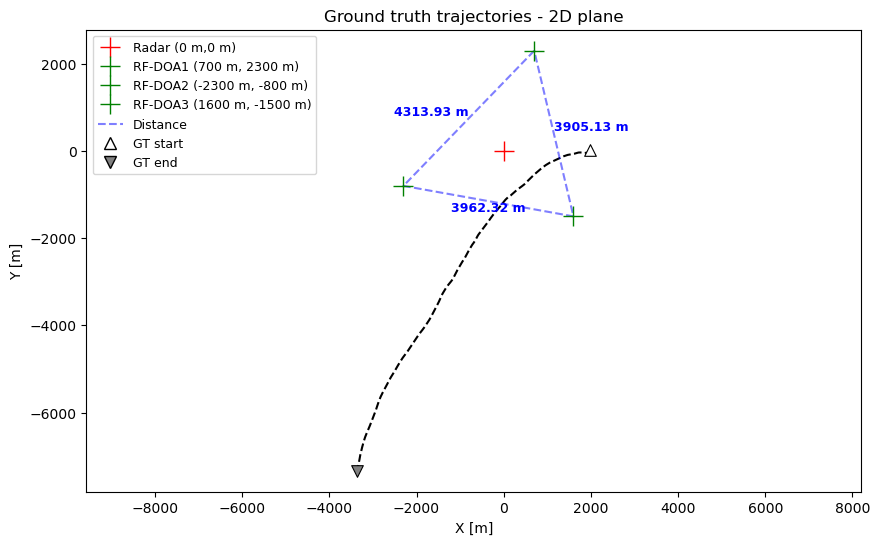

In [12]:
## 2D plot: Ground truth only + sensor position

plotter_gt = Plotter(dimension=Dimension.TWO)
plotter_gt.plot_ground_truths(truths, [0, 2], color='black')
plotter_gt.ax.plot(0, 0, 'r+', markersize=14, zorder=5, label='Radar (0 m,0 m)')
plotter_gt.ax.plot(700, 2300, 'g+', markersize=14, zorder=5, label='RF-DOA1 (700 m, 2300 m)')
plotter_gt.ax.plot(-2300, -800, 'g+', markersize=14, zorder=5, label='RF-DOA2 (-2300 m, -800 m)')
plotter_gt.ax.plot(1600, -1500, 'g+', markersize=14, zorder=5, label='RF-DOA3 (1600 m, -1500 m)')

x_coords = [700, -2300, 1600, 700]
y_coords = [2300, -800, -1500, 2300]
plotter_gt.ax.plot(x_coords, y_coords, color='blue', linestyle='--', alpha = 0.5, linewidth=1.5, zorder=4, label='Distance')


plotter_gt.ax.text((700 - 2300)/2, (2300 - 800)/2, '4313.93 m', 
                   color='blue', fontsize=9, fontweight='bold', ha='right', va='bottom')

plotter_gt.ax.text((-2300 + 1600)/2, (-800 - 1500)/2, '3962.32 m', 
                   color='blue', fontsize=9, fontweight='bold', ha='center', va='top')

plotter_gt.ax.text((700 + 1600)/2, (2300 - 1500)/2, '3905.13 m', 
                   color='blue', fontsize=9, fontweight='bold', ha='left', va='bottom')

plotter_gt.ax.set_title('Ground truth trajectories - 2D plane')
plotter_gt.ax.legend(loc='upper left', fontsize=9)
plotter_gt.ax.set_xlabel('X [m]')
plotter_gt.ax.set_ylabel('Y [m]')

plot_gt_endpoints(plotter_gt.ax, truths, mapping=(0, 2))

handles, labels = plotter_gt.ax.get_legend_handles_labels()
plotter_gt.ax.legend(handles=handles + ENDPOINT_LEGEND[2:],  # solo GT start/end
                     loc='upper left', fontsize=9)

Text(0, 0.5, 'Z [m]')

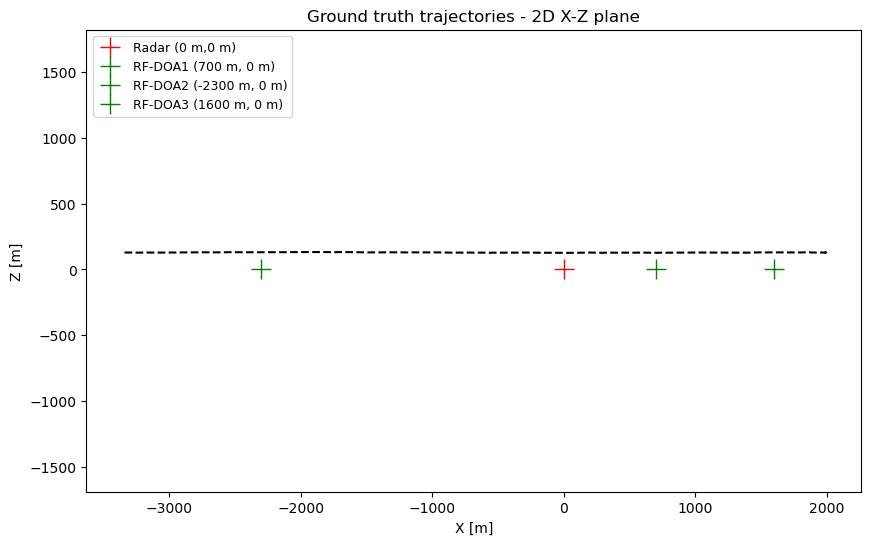

In [13]:
## 2D (X-Z plane) plot: Ground truth only + sensor position

plotter_gt = Plotter(dimension=Dimension.TWO)
plotter_gt.plot_ground_truths(truths, [0, 4], color='black')
plotter_gt.ax.plot(0, 0, 'r+', markersize=14, zorder=5, label='Radar (0 m,0 m)')
plotter_gt.ax.plot(700, 0, 'g+', markersize=14, zorder=5, label='RF-DOA1 (700 m, 0 m)')
plotter_gt.ax.plot(-2300, 0, 'g+', markersize=14, zorder=5, label='RF-DOA2 (-2300 m, 0 m)')
plotter_gt.ax.plot(1600, 0, 'g+', markersize=14, zorder=5, label='RF-DOA3 (1600 m, 0 m)')
plotter_gt.ax.set_title('Ground truth trajectories - 2D X-Z plane')
plotter_gt.ax.legend(loc='upper left', fontsize=9)
plotter_gt.ax.set_xlabel('X [m]')
plotter_gt.ax.set_ylabel('Z [m]')


Text(0, 0.5, 'Z [m]')

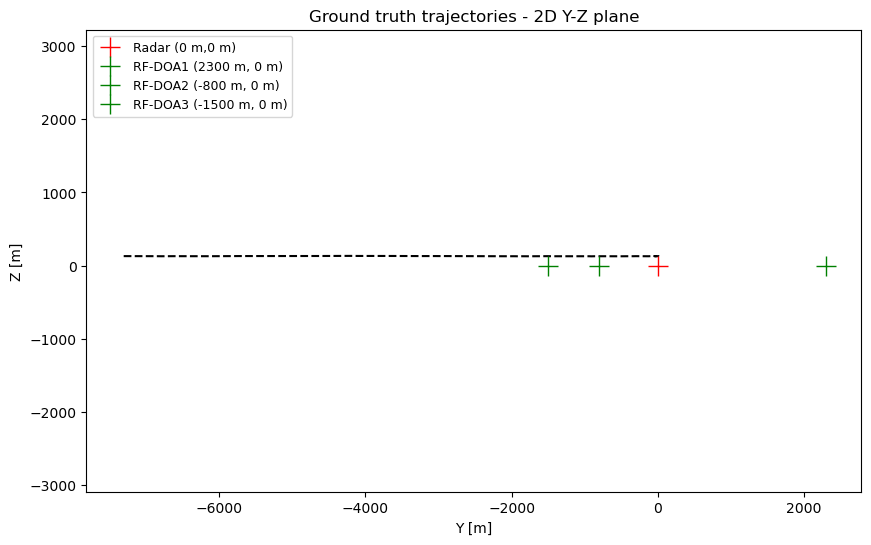

In [14]:
## 2D (Y-Z plane) plot: Ground truth only + sensor position

plotter_gt = Plotter(dimension=Dimension.TWO)
plotter_gt.plot_ground_truths(truths, [2, 4], color='black')
plotter_gt.ax.plot(0, 0, 'r+', markersize=14, zorder=5, label='Radar (0 m,0 m)')
plotter_gt.ax.plot(2300, 0, 'g+', markersize=14, zorder=5, label='RF-DOA1 (2300 m, 0 m)')
plotter_gt.ax.plot(-800, 0, 'g+', markersize=14, zorder=5, label='RF-DOA2 (-800 m, 0 m)')
plotter_gt.ax.plot(-1500, 0, 'g+', markersize=14, zorder=5, label='RF-DOA3 (-1500 m, 0 m)')
plotter_gt.ax.set_title('Ground truth trajectories - 2D Y-Z plane')
plotter_gt.ax.legend(loc='upper left', fontsize=9)
plotter_gt.ax.set_xlabel('Y [m]')
plotter_gt.ax.set_ylabel('Z [m]')


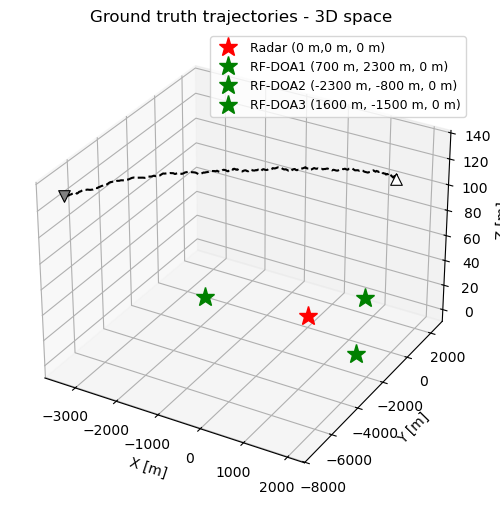

In [15]:
## 3D plot: Ground truth only + sensors position

plotter_gt_3d = Plotter(dimension=Dimension.THREE)
plotter_gt_3d.plot_ground_truths(truths, [0, 2, 4], color='black')
plotter_gt_3d.ax.plot(0,0,0, 'r*', markersize=14, zorder=5, label='Radar (0 m,0 m, 0 m)')
plotter_gt_3d.ax.plot(700, 2300, 0, 'g*', markersize=14, zorder=5, label='RF-DOA1 (700 m, 2300 m, 0 m)')
plotter_gt_3d.ax.plot(-2300, -800, 0, 'g*', markersize=14, zorder=5, label='RF-DOA2 (-2300 m, -800 m, 0 m)')
plotter_gt_3d.ax.plot(1600, -1500, 0, 'g*', markersize=14, zorder=5, label='RF-DOA3 (1600 m, -1500 m, 0 m)')
plotter_gt_3d.ax.set_title('Ground truth trajectories - 3D space')
plotter_gt_3d.ax.legend(loc='upper right', fontsize=9)
plotter_gt_3d.ax.set_xlabel('X [m]')
plotter_gt_3d.ax.set_ylabel('Y [m]')
plotter_gt_3d.ax.set_zlabel('Z [m]')
plot_gt_endpoints_3d(plotter_gt_3d.ax, truths)
plt.show()


## Radar Detections vs. Ground Truth

This plot overlays raw radar detections (including clutter, since no filtering is applied before plotting) against ground truth trajectories on the X-Y plane. Its conceptual role is to visually validate the radar sensor model's behavior prior to tracking.

Text(0.5, 1.0, 'Radar detections and ground truth - X-Y ground plane')

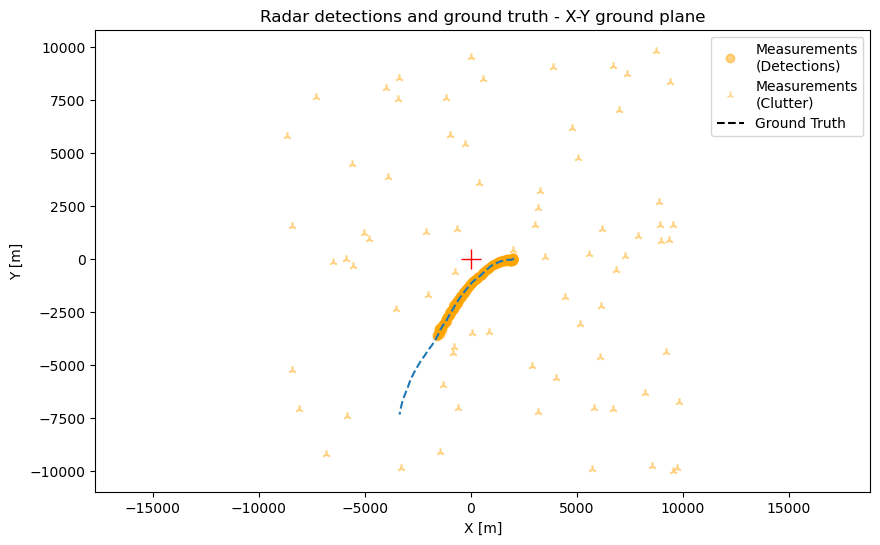

In [16]:
# Plot: 2D radar detections and GT

plotter = Plotter(Dimension.TWO)
plotter.plot_measurements(radar_detections, [0, 2], color='orange', marker='o', alpha=0.5)
plotter.plot_ground_truths(truths, [0, 2])
plotter.ax.set_xlabel('X [m]')
plotter.ax.set_ylabel('Y [m]')

# Platform marker
plotter.ax.plot(0, 0, 'r+', markersize=15, zorder=5, label='Radar (0 m, 0 m)')

# title
plotter.ax.set_title('Radar detections and ground truth - X-Y ground plane')


Text(0.5, 0.92, 'Radar detections and ground truth - 3D ground plane')

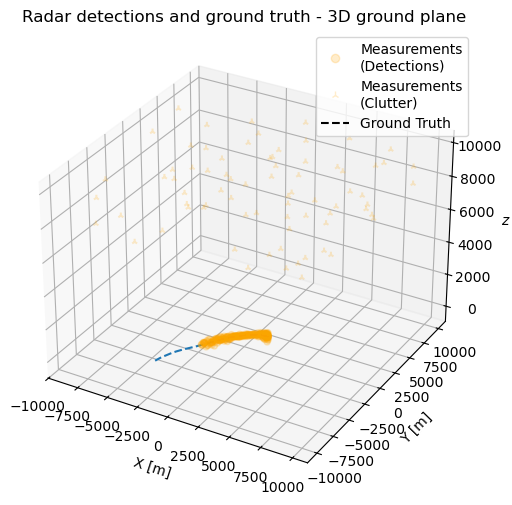

In [17]:
# Plot: 3D radar detections and GT
plotter = Plotter(Dimension.THREE)
plotter.plot_measurements(radar_detections, [0, 2,4], color='orange', marker='o', alpha=0.2)
plotter.plot_ground_truths(truths, [0, 2, 4], alpha=1)
plotter.ax.set_xlabel('X [m]')
plotter.ax.set_ylabel('Y [m]')
plotter.ax.set_title('Radar detections and ground truth - 3D ground plane')


## RF-DOA Bearing Rays Visualization

Rather than plotting point detections (impossible for bearing-only sensors), this renders each measured azimuth as a ray from sensor origin, visualizing the raw angular information available pre-triangulation. True-detection rays should visibly converge near ground truth trajectories; clutter rays scatter randomly.

Text(0, 0.5, 'Y [m]')

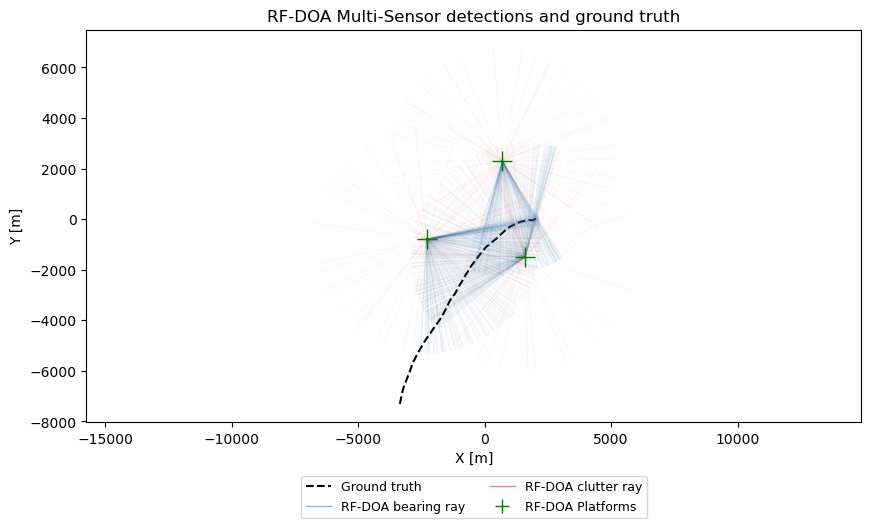

In [18]:
plotter = Plotter(dimension=Dimension.TWO)
plotter.plot_ground_truths(truths, [0, 2], color='black')

# RF-DOA: draw bearing rays from origin
RAY_LEN = 4500   # arbitrary display length [m]

# Dictionaru to map sensors with their coordinates
# Format: (x_origin, y_origin): (true_detections, clutter_detections)
rfdoa_sensors_data = {
    (700, 2300):   (rfdoa1_true, rfdoa1_clutter),
    (-2300, -800):    (rfdoa2_true, rfdoa2_clutter),
    (1600, -1500):  (rfdoa3_true, rfdoa3_clutter)
}

for (x_orig, y_orig), (true_dets, clutter_dets) in rfdoa_sensors_data.items():

    # Plot true detections
    for det in true_dets:
        b = float(det.state_vector[0])
        plotter.ax.plot(
            [x_orig, x_orig + RAY_LEN * np.cos(b)],
            [y_orig, y_orig + RAY_LEN * np.sin(b)],
            color='steelblue', alpha=0.04, linewidth=0.7
        )

    # Plot clutter detections
    for det in clutter_dets:
        b = float(det.state_vector[0])
        plotter.ax.plot(
            [x_orig, x_orig + RAY_LEN * np.cos(b)],
            [y_orig, y_orig + RAY_LEN * np.sin(b)],
            color='red', alpha=0.04, linewidth=0.6
        )

    # Platform marker per ciascun sensore
    plotter.ax.plot(x_orig, y_orig, 'g+', markersize=14, zorder=5)


# Legend
legend_elems = [
    Line2D([0], [0], color='black',     linestyle='--', lw=1.5,           label='Ground truth'),
    Line2D([0], [0], color='steelblue', lw=1,           alpha=0.6,        label='RF-DOA bearing ray'),
    Line2D([0], [0], color='red',       lw=1,           alpha=0.5,        label='RF-DOA clutter ray'),
    Line2D([0], [0], color='green',     lw=0,           marker='+', ms=10, label='RF-DOA Platforms'),
]

# put legend below plot like reference notebook
pos = plotter.ax.get_position()
plotter.ax.set_position([pos.x0, pos.y0 + 0.15, pos.width, pos.height * 0.85])
plotter.ax.legend(handles=legend_elems, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9)
plotter.ax.set_title('RF-DOA Multi-Sensor detections and ground truth')
plotter.ax.set_xlabel('X [m]')
plotter.ax.set_ylabel('Y [m]')


Text(0, 0.5, 'Y [m]')

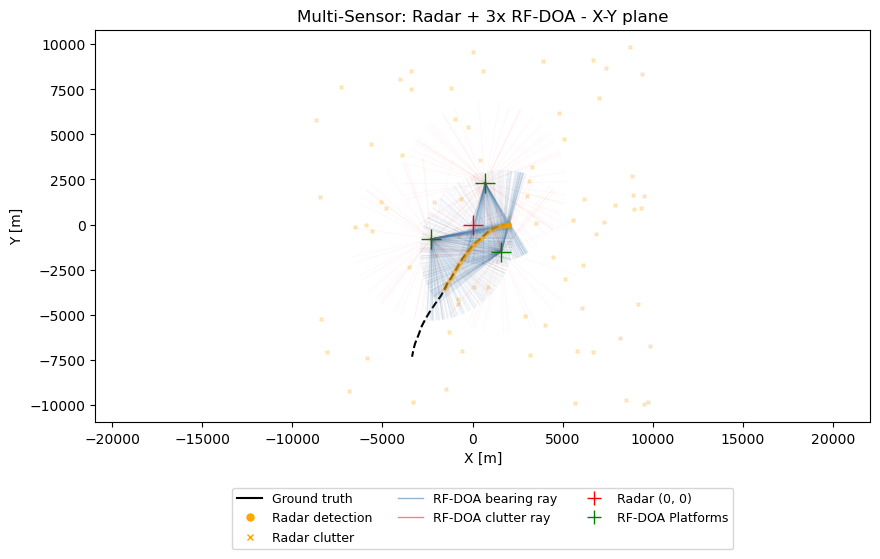

In [19]:
import numpy as np
from matplotlib.lines import Line2D

# Plot: Stone Soup Plotter (2-D, X-Y plane)

# Stone Soup plotter for ground truths
plotter = Plotter(dimension=Dimension.TWO)
plotter.plot_ground_truths(truths, [0, 2], color='black')


# Radar detections: convert (el, bearing, range) to (x, y) and overlay
def spherical_to_xy(det):
    sv = det.state_vector
    el, az, r = float(sv[0]), float(sv[1]), float(sv[2])
    x = r * np.cos(el) * np.cos(az)
    y = r * np.cos(el) * np.sin(az)
    return x, y


if radar_true:
    rxs, rys = zip(*[spherical_to_xy(d) for d in radar_true])
    plotter.ax.scatter(
        rxs, rys,
        s=6, c='orange', alpha=0.09, zorder=3, label='Radar detections',
    )

if radar_clutter:
    cxs, cys = zip(*[spherical_to_xy(d) for d in radar_clutter])
    plotter.ax.scatter(
        cxs, cys,
        s=6, c='orange', marker='x', alpha=0.3, label='Radar clutter',
    )

# RF-DOA: Define platforms and their respective detection sets
# Format: (x_origin, y_origin): (true_detections, clutter_detections)
rfdoa_mapping = {
    (700, 2300): (rfdoa1_true, rfdoa1_clutter),
    (-2300, -800): (rfdoa2_true, rfdoa2_clutter),
    (1600, -1500): (rfdoa3_true, rfdoa3_clutter),
}

RAY_LEN = 4500  # arbitrary display length [m]

for (x0, y0), (true_set, clutter_set) in rfdoa_mapping.items():
    # Draw true bearing rays
    for det in true_set:
        b = float(det.state_vector[0])
        plotter.ax.plot(
            [x0, x0 + RAY_LEN * np.cos(b)],
            [y0, y0 + RAY_LEN * np.sin(b)],
            color='steelblue', alpha=0.06, linewidth=0.7,
        )

    # Draw clutter bearing rays
    for det in clutter_set:
        b = float(det.state_vector[0])
        plotter.ax.plot(
            [x0, x0 + RAY_LEN * np.cos(b)],
            [y0, y0 + RAY_LEN * np.sin(b)],
            color='red', alpha=0.04, linewidth=0.6,
        )

    # Add platform marker for this RF-DOA sensor
    plotter.ax.plot(x0, y0, 'g+', markersize=14, zorder=5)

# Radar platform marker
plotter.ax.plot(0, 0, 'r+', markersize=14, zorder=5)

# Legend
legend_elems = [
    Line2D([0], [0], color='black', lw=1.5, label='Ground truth'),
    Line2D([0], [0], color='orange', lw=0, marker='o', ms=5, label='Radar detection'),
    Line2D([0], [0], color='orange', lw=0, marker='x', ms=5, label='Radar clutter'),
    Line2D([0], [0], color='steelblue', lw=1, alpha=0.6, label='RF-DOA bearing ray'),
    Line2D([0], [0], color='red', lw=1, alpha=0.5, label='RF-DOA clutter ray'),
    Line2D([0], [0], color='red', lw=0, marker='+', ms=10, label='Radar (0, 0)'),
    Line2D([0], [0], color='green', lw=0, marker='+', ms=10, label='RF-DOA Platforms'),
]

# Adjust layout to fit legend below
pos = plotter.ax.get_position()
plotter.ax.set_position([pos.x0, pos.y0 + 0.15, pos.width, pos.height * 0.85])
plotter.ax.legend(
    handles=legend_elems,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    fontsize=9,
)

plotter.ax.set_title('Multi-Sensor: Radar + 3x RF-DOA - X-Y plane')
plotter.ax.set_xlabel('X [m]')
plotter.ax.set_ylabel('Y [m]')


## Pre-Tracking Error Characterization

This block performs a sensor-level error analysis decoupled from the tracking pipeline, with the conceptual goal of validating that each sensor's simulated measurement noise matches its specified statistical model **before** any filtering, association, or fusion logic is introduced. This separation is methodologically important: if tracker performance is poor, this analysis allows isolating whether the cause lies in the sensor model itself or in the downstream estimation/association logic.

**Radar errors** are evaluated in two complementary coordinate frames. First, in the sensor's native spherical frame (elevation, azimuth, range) — directly comparable to the `CartesianToElevationBearingRange` noise covariance configured on the radar, since this is the frame in which measurement noise is actually injected. Second, detections are converted to Cartesian (`sphere2cart`) and compared against ground truth in (x, y, z), giving an absolute positional error. Azimuth error is wrapped to (−π, π] before conversion to degrees to correctly handle the angular discontinuity at ±180°, avoiding spurious large errors from wraparound.

**RF-DOA errors** are necessarily evaluated only in bearing, since a bearing-only sensor has no range information and Cartesian position error is undefined prior to triangulation. The true bearing is computed geometrically via `arctan2` on the vector from each sensor's known position to the ground truth target position, and compared against the simulated detection's bearing. This per-sensor RMSE is the key validation metric for the RF-DOA noise model (`rf_noise_covar`) and is later directly relevant when assessing the consistency of the triangulation engine's Jacobian-based covariance propagation — since that propagation assumes this same bearing noise as its input uncertainty.

                       REPORT: ERRORS                       
RADAR - 3D RMSE: 95.451 m
RADAR - Max error -> X: 81.24m, Y: 60.02m, Z: 348.50m
------------------------------------------------------------
RADAR - Max Error -> Elevation: 10.313 deg, Azimuth: 2.028 deg, Range: 9.34m
RADAR - RMSE -> Elevation: 2.806 deg Azimuth: 0.756 deg Range: 3.114m
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
RF-DOA 1 - RMSE Bearing: 1.476 deg
RF-DOA 1 - Bearing error -> Max: 4.442 deg, Min: 0.019 deg
------------------------------
RF-DOA 2 - RMSE Bearing: 21.955 deg
RF-DOA 2 - Bearing error -> Max: 33.537 deg, Min: 0.188 deg
------------------------------
RF-DOA 3 - RMSE Bearing: 1.451 deg
RF-DOA 3 - Bearing error -> Max: 4.095 deg, Min: 0.000 deg
------------------------------


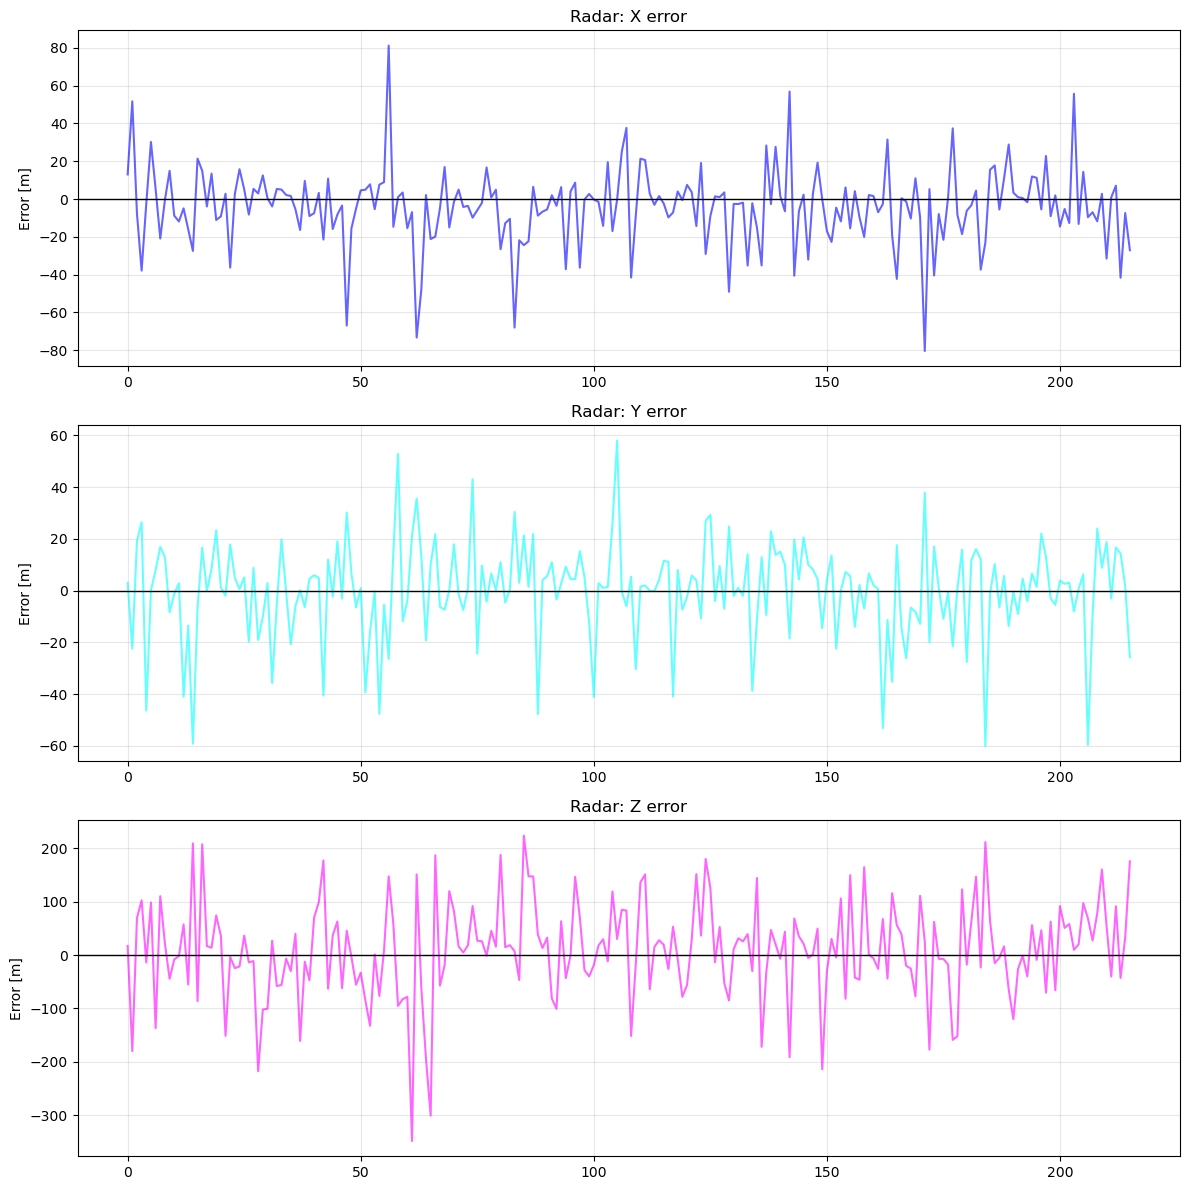

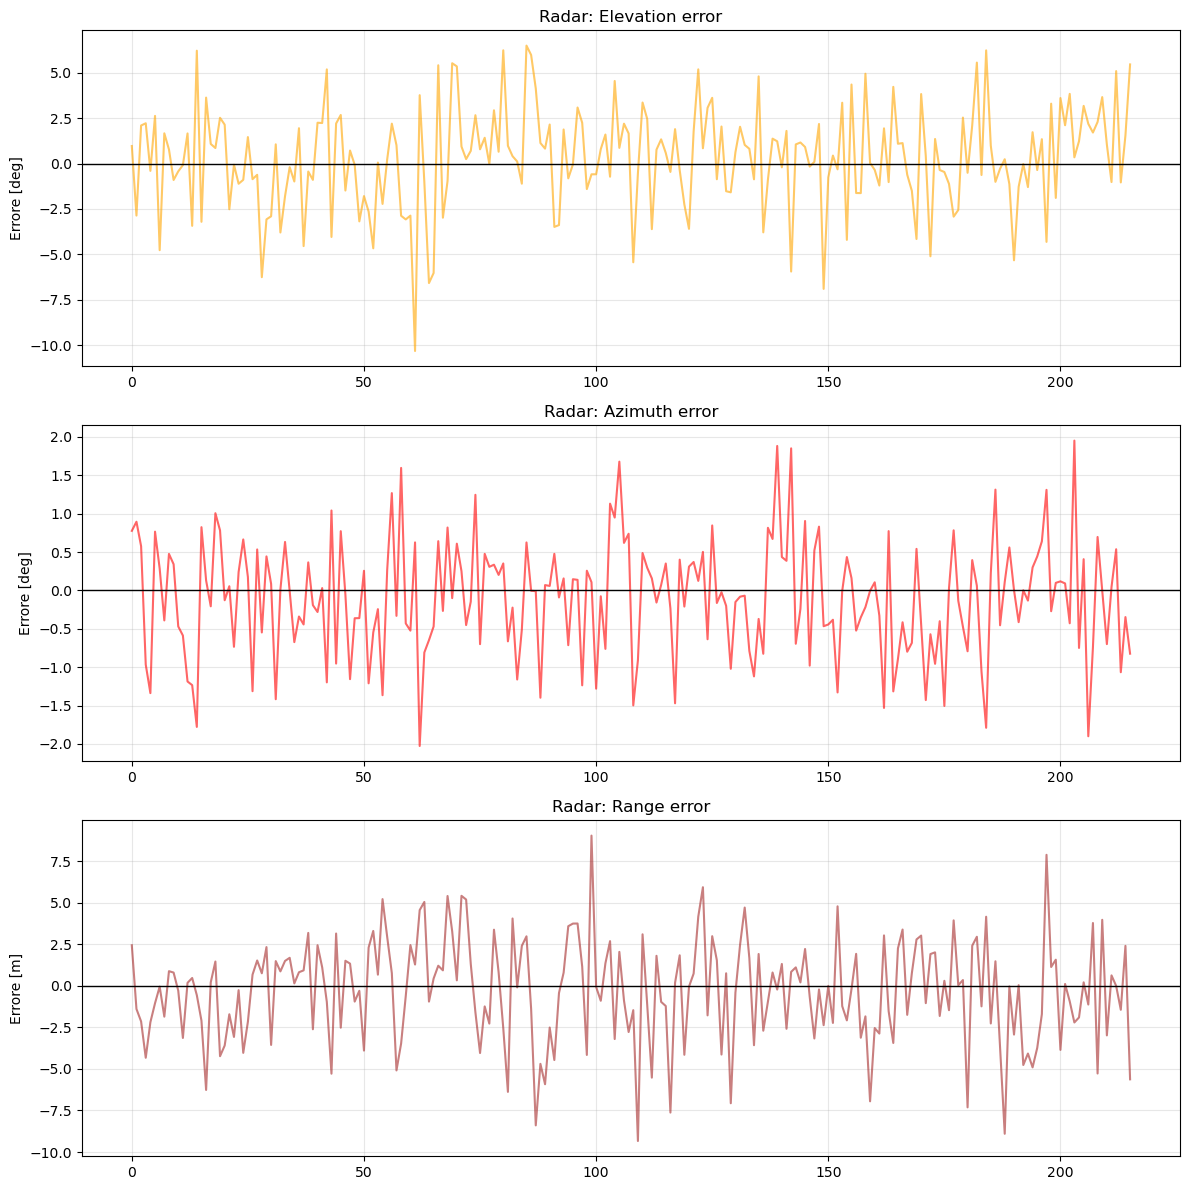

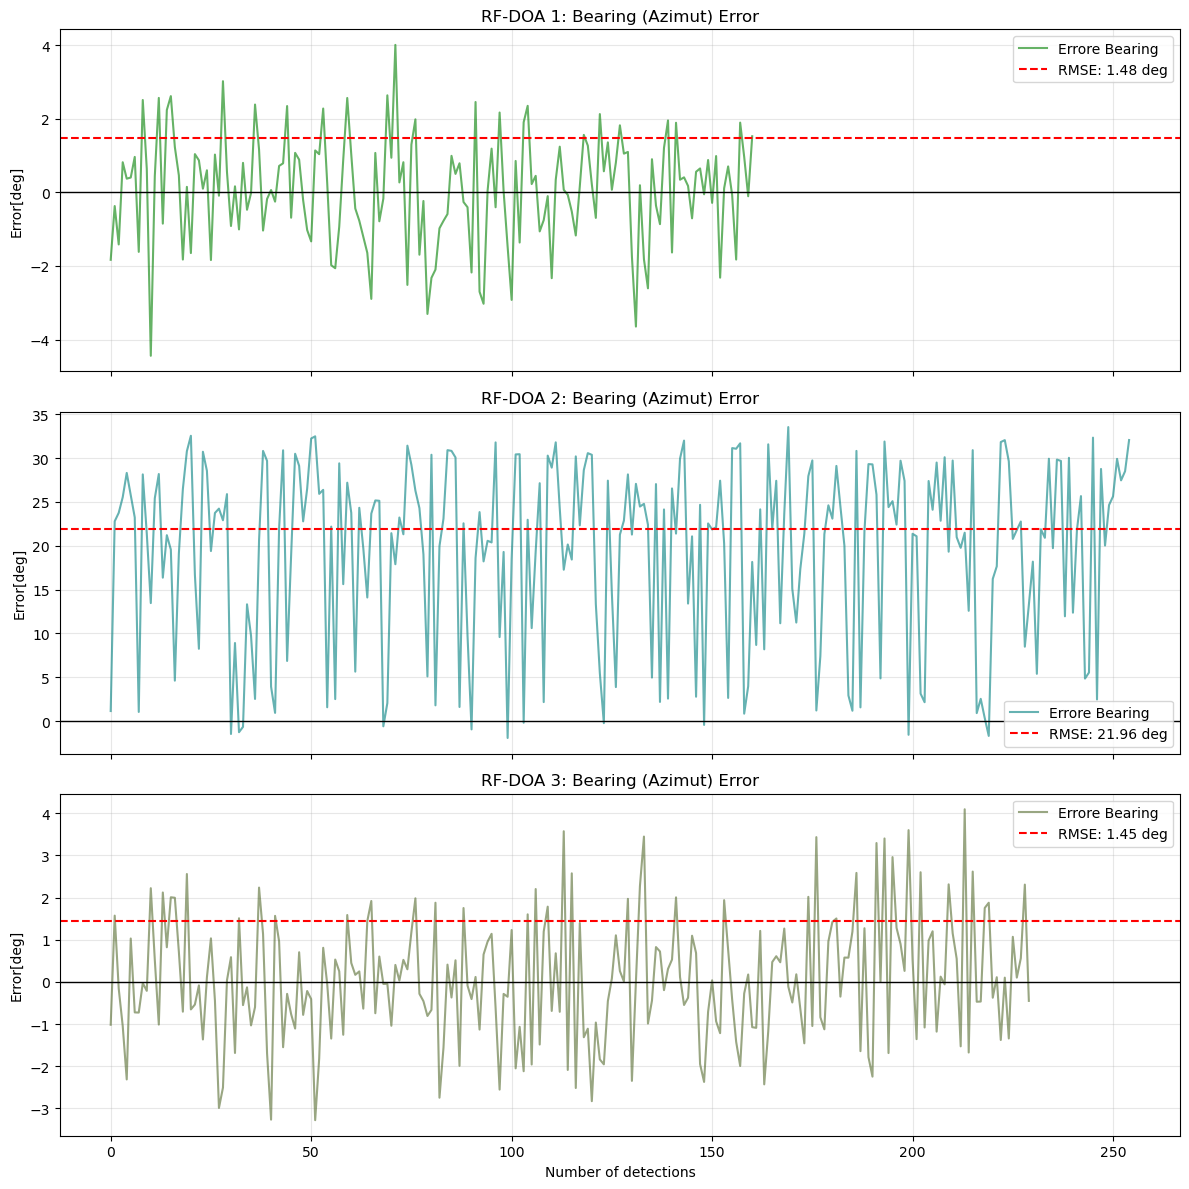

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from stonesoup.functions import cart2sphere, sphere2cart


def get_rmse(arr):
    if len(arr) == 0:
        return 0.0
    return np.sqrt(np.mean(np.array(arr) ** 2))


# Radar lists
err_r_x, err_r_y, err_r_z = [], [], []
err_r_el, err_r_az, err_r_range = [], [], []

# RF-DOA error storage (using a dictionary for the 3 sensors)
rfdoa_error_data = {
    "RF-DOA 1": {"errors": [], "pos": np.array([700, 2300]), "dets": rfdoa1_true},
    "RF-DOA 2": {"errors": [], "pos": np.array([-2300, 800]), "dets": rfdoa2_true},
    "RF-DOA 3": {"errors": [], "pos": np.array([1600, -1500]), "dets": rfdoa3_true},
}

# Sensors position
pos_radar = np.array([0, 0, 0])

# Radar Errors
for det in radar_true:
    # GT
    gt_state = det.groundtruth_path[det.timestamp]
    gt_pos = gt_state.state_vector[[0, 2, 4], 0]  # [x, y, z]

    # --- Cartesian metrics ---
    # spherical to cartesian radar
    el_d = float(det.state_vector[0])
    az_d = float(det.state_vector[1])
    r_d = float(det.state_vector[2])

    x_d, y_d, z_d = sphere2cart(r_d, az_d, el_d)

    # XYZ error
    err_r_x.append(x_d - gt_pos[0])
    err_r_y.append(y_d - gt_pos[1])
    err_r_z.append(z_d - gt_pos[2])

    # --- Spherical metrics ---
    # cartesian GT to spherical
    gt_r, gt_az, gt_el = cart2sphere(gt_pos[0], gt_pos[1], gt_pos[2])

    err_r_el.append(np.degrees(el_d - gt_el))
    err_r_az.append(np.degrees((az_d - gt_az + np.pi) % (2 * np.pi) - np.pi))
    err_r_range.append(r_d - gt_r)

# RF-DOA Errors for all 3 sensors
for name, data in rfdoa_error_data.items():
    sensor_pos = data["pos"]
    for det in data["dets"]:
        gt_state = det.groundtruth_path[det.timestamp]
        gt_pos_xy = gt_state.state_vector[[0, 2], 0]

        bearing_d = float(det.state_vector[0])

        # GT bearing
        v_rel = gt_pos_xy - sensor_pos
        bearing_gt = np.arctan2(v_rel[1], v_rel[0])

        err_ang = (bearing_d - bearing_gt + np.pi) % (2 * np.pi) - np.pi
        data["errors"].append(np.degrees(err_ang))


rmse_3d_radar = np.sqrt(
    np.mean(np.array(err_r_x) ** 2 + np.array(err_r_y) ** 2 + np.array(err_r_z) ** 2)
)

print("=" * 60)
print(f"{'REPORT: ERRORS':^60}")
print("=" * 60)

print(f"RADAR - 3D RMSE: {rmse_3d_radar:.3f} m")

print(
    f"RADAR - Max error -> "
    f"X: {np.max(np.abs(err_r_x)):.2f}m, "
    f"Y: {np.max(np.abs(err_r_y)):.2f}m, "
    f"Z: {np.max(np.abs(err_r_z)):.2f}m"
)

print("-" * 60)

print(
    f"RADAR - Max Error -> "
    f"Elevation: {np.max(np.abs(err_r_el)):.3f} deg, "
    f"Azimuth: {np.max(np.abs(err_r_az)):.3f} deg, "
    f"Range: {np.max(np.abs(err_r_range)):.2f}m"
)

print(
    f"RADAR - RMSE -> "
    f"Elevation: {get_rmse(err_r_el):.3f} deg "
    f"Azimuth: {get_rmse(err_r_az):.3f} deg "
    f"Range: {get_rmse(err_r_range):.3f}m"
)

print("+" * 60)

# Print RF-DOA errors matching original style
for name, data in rfdoa_error_data.items():
    errs = data["errors"]
    if not errs:
        continue

    print(f"{name} - RMSE Bearing: {get_rmse(errs):.3f} deg")
    print(
        f"{name} - Bearing error -> "
        f"Max: {np.max(np.abs(errs)):.3f} deg, "
        f"Min: {np.min(np.abs(errs)):.3f} deg"
    )
    print("-" * 30)

print("=" * 60)


# --- 3. PLOTS ---

# --- FIGURE 1: (X, Y, Z) ---
fig1, axs1 = plt.subplots(3, 1, figsize=(12, 12))

coords = [
    ("X", err_r_x, "blue"),
    ("Y", err_r_y, "cyan"),
    ("Z", err_r_z, "magenta"),
]

for i, (name, data, color) in enumerate(coords):
    axs1[i].plot(data, color=color, alpha=0.6)
    axs1[i].axhline(0, color="black", lw=1)
    axs1[i].set_title(f"Radar: {name} error")
    axs1[i].set_ylabel("Error [m]")
    axs1[i].grid(True, alpha=0.3)

plt.tight_layout()

# --- FIGURE 2: RADAR Error (El, Az, Range) ---
fig2, axs2 = plt.subplots(3, 1, figsize=(12, 12))

polars = [
    ("Elevation", err_r_el, "orange", "deg"),
    ("Azimuth", err_r_az, "red", "deg"),
    ("Range", err_r_range, "brown", "m"),
]

for i, (name, data, color, unit) in enumerate(polars):
    axs2[i].plot(data, color=color, alpha=0.6)
    axs2[i].axhline(0, color="black", lw=1)
    axs2[i].set_title(f"Radar: {name} error")
    axs2[i].set_ylabel(f"Errore [{unit}]")
    axs2[i].grid(True, alpha=0.3)

plt.tight_layout()

# --- FIGURE 3: RF-DOA BEARING (3 Subplots) ---
fig3, axs3 = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
colors_rf = ["green", "teal", "darkolivegreen"]

for i, (name, data) in enumerate(rfdoa_error_data.items()):
    errs = data["errors"]
    if not errs:
        continue

    axs3[i].plot(errs, color=colors_rf[i], alpha=0.6, label="Errore Bearing")
    rmse = get_rmse(errs)
    axs3[i].axhline(rmse, color="red", linestyle="--", label=f"RMSE: {rmse:.2f} deg")
    axs3[i].axhline(0, color="black", lw=1)

    axs3[i].set_title(f"{name}: Bearing (Azimut) Error")
    axs3[i].set_ylabel("Error[deg]")
    axs3[i].legend()
    axs3[i].grid(True, alpha=0.3)

plt.xlabel("Number of detections")
plt.tight_layout()

plt.show()


## Radar JPDA Tracker Configuration 

This block configures a complete multi-target tracking pipeline dedicated exclusively to the radar sensor, conceptually separated from the RF-DOA tracking chain so that each modality's tracking performance can be evaluated and tuned independently before fusion.

**Prediction model:** The Unscented Kalman filter is paired with a transition model assuming decoupled `ConstantVelocity` dynamics on x, y, and z, each with a relatively high process noise intensity. This is a deliberate design choice rather than an attempt to match the true target dynamics: the ground truth simulators generate maneuvering targets (turn-rate, spiral, model-switching), but the tracker's transition model is intentionally simpler and noisier. This is standard JPDA/UKF practice — a high process noise inflates the predicted covariance enough to maintain track continuity through unmodeled maneuvers, trading a less efficient (data-driven) filter for robustness against model mismatch, since explicitly matching every possible truth-generating model in the tracker would be both unrealistic (a real tracker doesn't know the target's true motion model) and brittle.

**Choice of UKF over EKF:** The radar's measurement model (`CartesianToElevationBearingRange`) is a nonlinear spherical-to-Cartesian transformation. UKF is preferred here over EKF because it avoids explicit Jacobian computation and tends to better capture the true nonlinear measurement uncertainty via sigma-point propagation, particularly relevant at longer ranges or steep elevation angles where the EKF's first-order linearization degrades.

**Data association: PDA hypothesiser + JPDA.** `Pd = 0.95` reflects a near-but-not-unity probability of detection per scan, consistent with a realistic radar detection model rather than an idealized always-detect assumption. JPDA (rather than simple nearest-neighbour or GNN) is selected because it computes association probabilities jointly across all track-detection pairs, which is essential in this multi-target scenario where birth/death processes and crossing trajectories regularly produce ambiguous, overlapping gating regions.

**Track deletion:** `UpdateTimeStepsDeleter(time_steps_since_update=10)` removes a track after 10 consecutive scans without an associated update. This threshold is a tradeoff: long enough to survive brief occlusions or missed detections under `Pd=0.95`, but short enough to prune genuinely dead tracks.

**Track initiation:** `MultiMeasurementInitiator` utilises features of the tracker to initiate and hold tracks temporarily within the initiator itself, releasing them to the tracker once there are multiple detections associated with them enough to determine that they are ‘sure’ tracks. It utilises simple initiator to initiate tracks to hold and prevents code duplication.
Requiring `min_detections = 10` consistent detections before confirming a track is a deliberate confirmation-logic choice to suppress false track formation from clutter, at the cost of a longer track-establishment latency. The initiator's own internal association uses `NearestNeighbour` rather than JPDA: this is intentional, since during the tentative/unconfirmed phase there is no established track state yet to support full joint probabilistic association, and a simpler, cheaper association rule suffices for the candidate-track aggregation stage. `skip_non_reversible=True` is safe here specifically because `CartesianToElevationBearingRange` **is** a reversible model unlike `Cartesian2DToBearing`; for the radar branch, reversibility is satisfied, so the inverse-measurement-based initial state estimate can be computed correctly. The `initiator_prior_state` covariance (1000² m² in position, 50² m²/s² in horizontal velocity, smaller in z) reflects a deliberately broad, weakly-informative prior, consistent with not yet having any confirmed knowledge about a candidate track's true kinematic state at first detection.

**Tracker assembly.** `MultiTargetMixtureTracker` ties together initiator, deleter, associator, and updater, fed exclusively by `radar_tracker_input`.

In [21]:
## Setup the radar tracking algorithm

ukp_trans_mod =  CombinedGaussianTransitionModel([
    ConstantVelocity(q),
    ConstantVelocity(q),
    ConstantVelocity(q),
])


# Instance of ExtendedKalmanPredictor class

predictor = UnscentedKalmanPredictor(ukp_trans_mod)

# Instance of ExtendedKalmanUpdater

updater = UnscentedKalmanUpdater(measurement_model = None)


In [22]:
## Data Association

# Create a PDAHypothesiser instance.

hypothesiser = PDAHypothesiser(predictor = predictor,
                               updater = updater,
                               clutter_spatial_density = 2.5e-13,
                               prob_detect = Pd_radar)

# JPDA Associator instance

data_associator = JPDA(hypothesiser = hypothesiser)


In [23]:
## Delete tracks if no measurements have fallen within the JPDA gating region in 3 time steps.


# Deleter instance

deleter = UpdateTimeStepsDeleter(time_steps_since_update = 10)


In [24]:
## Initiator definition

min_detections = 40 # number of detections required to begin a track

initiator_prior_state = GaussianState(
    state_vector = np.array([[0], [0], [0], [0], [0], [0]]), covar = np.diag([1000, 50, 1000, 50, 500, 20])**2
)

# The measurement model of the sensor is used because the overall data stream is composed by
# detections of this type.

initiator_meas_model = CartesianToElevationBearingRange(
    ndim_state = 10,
    mapping = np.array([0, 2, 4]),
    noise_covar = noise_covar
)

# Create the Initiator object for tracker

initiator = MultiMeasurementInitiator(
    prior_state = initiator_prior_state,
    measurement_model = initiator_meas_model,
    deleter = deleter,
    data_associator = NearestNeighbour(hypothesiser),
    updater = updater,
    min_points = min_detections,
    updates_only = True,
    skip_non_reversible = True
)


In [25]:
## JPDA Multi-target Tracker - Radar only
# NOTE: radar_tracker_input contains ONLY radar detections (no RF-DOA)

JPDA_radar_tracker = MultiTargetMixtureTracker(
    initiator = initiator,
    deleter = deleter,
    detector = radar_tracker_input,   # SOLO detection radar
    data_associator = data_associator,
    updater = updater
)

/var/folders/l_/zdf9yxfx6jvblmyt0jgt45xr0000gn/T/ipykernel_37201/2555316218.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_radar = plt.cm.get_cmap('tab10', len(radar_tracks))
/var/folders/l_/zdf9yxfx6jvblmyt0jgt45xr0000gn/T/ipykernel_37201/2555316218.py:37: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "go" (-> marker='o'). The keyword argument will take precedence.
  plotter2d.ax.plot(700, 2300, 'go', marker='+', markersize=10, markeredgewidth=2, label='RF-DOA (700, 2300)', zorder=10)
/var/folders/l_/zdf9yxfx6jvblmyt0jgt45xr0000gn/T/ipykernel_37201/2555316218.py:38: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "go" (-> marker='o'). The keyword argument will take precedence.
  plotter2d.ax.plot(-2300,

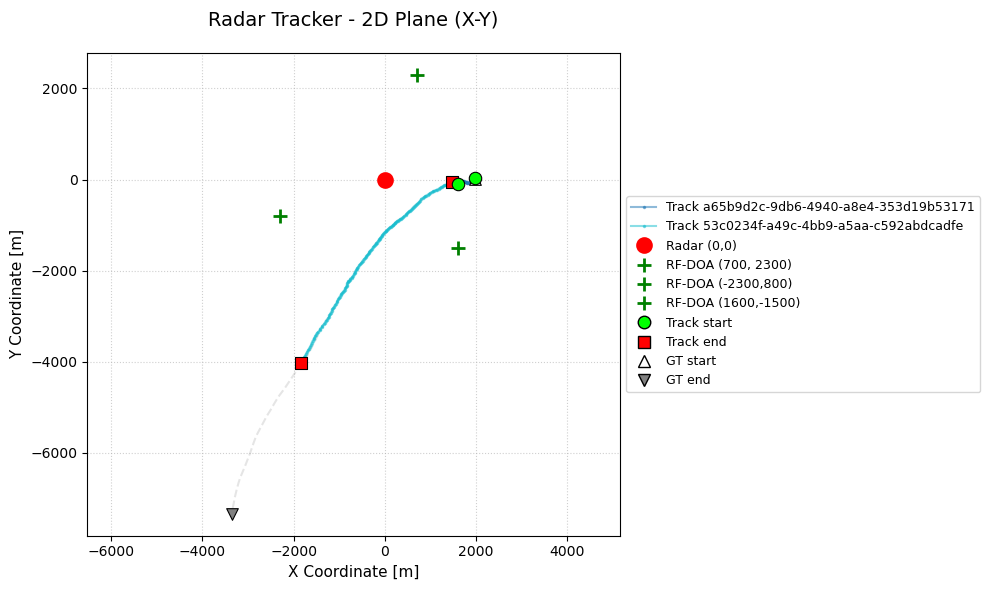

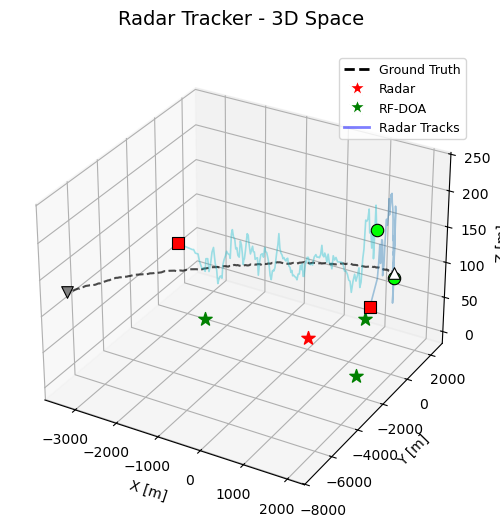

In [26]:
### Radar Tracking Loop & Advanced Plotting

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from stonesoup.plotter import Plotter, Dimension
import numpy as np


radar_tracks = set()
radar_snaps = []
for time, ctracks in JPDA_radar_tracker:
    radar_tracks.update(ctracks)
    radar_snaps.append((time, {Track([deepcopy(tr.state)], id=tr.id) for tr in ctracks}))


colors_radar = plt.cm.get_cmap('tab10', len(radar_tracks))

# -----------------------------------------------------------------
# 2D Plot - X-Y plane (Radar Tracker)
# -----------------------------------------------------------------
plotter2d = Plotter(dimension=Dimension.TWO)


plotter2d.plot_ground_truths(truths, [0, 2], color='black', linestyle='--', alpha=0.1)


for i, track in enumerate(radar_tracks):
    # Estraiamo le coordinate x (0) e y (2)
    tx = [state.state_vector[0, 0] for state in track.states]
    ty = [state.state_vector[2, 0] for state in track.states]
    
    plotter2d.ax.plot(tx, ty, marker='.', markersize=3, linewidth=1.5, 
                      color=colors_radar(i), alpha=0.5, label=f'Track {track.id}')


plotter2d.ax.plot(0, 0, 'ro', markersize=10, markeredgewidth=2, label='Radar (0,0)', zorder=10)
plotter2d.ax.plot(700, 2300, 'go', marker='+', markersize=10, markeredgewidth=2, label='RF-DOA (700, 2300)', zorder=10)
plotter2d.ax.plot(-2300, -800, 'go', marker='+', markersize=10, markeredgewidth=2, label='RF-DOA (-2300,800)', zorder=10)
plotter2d.ax.plot(1600, -1500, 'go', marker='+', markersize=10, markeredgewidth=2, label='RF-DOA (1600,-1500)', zorder=10)


plotter2d.ax.set_title('Radar Tracker - 2D Plane (X-Y)', fontsize=14, pad=20)
plotter2d.ax.set_xlabel('X Coordinate [m]', fontsize=11)
plotter2d.ax.set_ylabel('Y Coordinate [m]', fontsize=11)
plotter2d.ax.grid(True, linestyle=':', alpha=0.6)


plotter2d.ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9, ncol=1)

plt.tight_layout()

plot_track_endpoints(plotter2d.ax, radar_tracks)
plot_gt_endpoints(plotter2d.ax, truths)


handles, labels = plotter2d.ax.get_legend_handles_labels()
plotter2d.ax.legend(handles=handles + ENDPOINT_LEGEND,
                    loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.show()

# -----------------------------------------------------------------
# 3D Plot - X-Y-Z (Radar Tracker)
# -----------------------------------------------------------------
plotter3d = Plotter(dimension=Dimension.THREE)


plotter3d.plot_ground_truths(truths, [0, 2, 4], color='black', linestyle='--', alpha=0.7)


for i, track in enumerate(radar_tracks):
    tx = [state.state_vector[0, 0] for state in track.states]
    ty = [state.state_vector[2, 0] for state in track.states]
    tz = [state.state_vector[4, 0] for state in track.states]
    
    plotter3d.ax.plot(tx, ty, tz, linewidth=1.2, color=colors_radar(i), alpha=0.4)


plotter3d.ax.scatter(0, 0, 0, color='red', s=100, marker='*', label='Radar Platform', zorder=10)
plotter3d.ax.scatter(700, 2300, 0, color='green', s=100, marker='*', label='RF-DOA Platform', zorder=10)
plotter3d.ax.scatter(-2300, -800, 0, color='green', s=100, marker='*', label='RF-DOA Platform', zorder=10)
plotter3d.ax.scatter(1600, -1500, 0, color='green', s=100, marker='*', label='RF-DOA Platform', zorder=10)


plotter3d.ax.set_title('Radar Tracker - 3D Space', fontsize=14, pad=20)
plotter3d.ax.set_xlabel('X [m]')
plotter3d.ax.set_ylabel('Y [m]')
plotter3d.ax.set_zlabel('Z [m]')


custom_lines = [Line2D([0], [0], color='black', lw=2, linestyle='--'),
                Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=12),
                Line2D([0], [0], marker='*', color='w', markerfacecolor='green', markersize=12),
                Line2D([0], [0], color='blue', lw=2, alpha=0.5)]

plotter3d.ax.legend(custom_lines, ['Ground Truth', 'Radar', 'RF-DOA', 'Radar Tracks'], 
                    loc='upper right', fontsize=9)

plot_track_endpoints_3d(plotter3d.ax, radar_tracks)
plot_gt_endpoints_3d(plotter3d.ax, truths)

plt.show()

---
## RF-DOA Tracker 



### Architecture

```
Sensors (x3)                                           
RF-DOA 1 -> bearing1(t) --+
RF-DOA 2 -> bearing2(t) --+--> TRIANGULATION ENGINE --> CartesianToBearingRange dets -> JPDA Tracker (UKF) -> Tracks
RF-DOA 3 -> bearing3(t) --+                                    (bearing, range) 
                                                           
```


# Stage 1 — Adaptive Multi-Sensor RF-DOA Triangulation

## General architecture

The triangulation engine converts raw bearings from the three RF-DOA sensors
into cartographic detections `(bearing, range)` ready for the JPDA tracker.
It operates in seven distinct steps at each time step.

---

## Step 1 — Bearing collection

Each RF-DOA sensor produces at every time step a set of bearings — both real
drone measurements and stochastically generated clutter bearings.
The triangulation engine collects all bearings without distinction:

```python
s_rays[i] = [float(d.state_vector[0]) for d in dets_sensor_i]
```

Filtering of false detections is performed geometrically in subsequent steps,
not by detection type. If fewer than 2 sensors are active the step is skipped.

---

## Step 2 — Candidate generation via pairwise intersection

With 3 sensors, 3 possible pairs are formed: `(S1,S2)`, `(S1,S3)`, `(S2,S3)`.
For each pair, **all** intersections between every combination of bearings
from the two sensors are computed.

**Why pairs and not triplettes directly?**
With N drones each sensor observes N bearings but does not know which bearing
belongs to which drone. Feeding all bearings simultaneously into the 3×2 system
would produce a physically meaningless result. Pairs generate all possible
candidate points; step 3 identifies which ones are real.

**Bearing line equation** — bearing `β` from sensor `(sx, sy)` defines the line:

```
sin(β)·x − cos(β)·y = sin(β)·sx − cos(β)·sy
```

**Intersection of two lines** — 2×2 linear system:

```
A · p = b

A = [[sin(β₁), −cos(β₁)],    b = [sin(β₁)·s1x − cos(β₁)·s1y]
     [sin(β₂), −cos(β₂)]]        [sin(β₂)·s2x − cos(β₂)·s2y]
```

The determinant `det(A) = sin(β₁ − β₂)` measures the angle between the two
rays. If `|det| < sin(10°)` the lines are nearly parallel and the intersection
is numerically unstable: the candidate point is discarded. This **10° threshold**
is far more conservative than the original version (0.06°) and eliminates
degenerate geometries at the root.

---

## Step 3 — Consensus verification

For each candidate point, all active sensors are queried:
*"does your bearing ray pass close to this point?"*

For each sensor the perpendicular distance from the point to the bearing line
is computed:

```
d_perp = |sin(β)·(x − sx) − cos(β)·(y − sy)|
```

If `d_perp < 400 m` the sensor "votes" for that point and its bearing is added
to `contrib_bearings`. The tangential projection `t > −100 m` is also checked
to ensure the point lies in front of the sensor, not behind it.

| Point type | Votes | Outcome |
|---|---|---|
| Real target | 3/3 sensors | kept, highest priority |
| Ghost from wrong pair | 2/3 sensors | kept, lower priority |
| Isolated clutter point | 1/3 sensors | **discarded** |

At the end of this step, each surviving candidate is associated with the
specific bearings that confirm it — stored in `contrib_bearings` and
`contrib_pos`.

---

## Step 4 — Position refinement

Now that it is known which bearings belong to the same point, all available
information is used for the optimal position estimate.

### 3 sensors confirm — overdetermined 3×2 system

```
A = [[sin(β₁), −cos(β₁)],
     [sin(β₂), −cos(β₂)],    c = [c₁, c₂, c₃]
     [sin(β₃), −cos(β₃)]]

p = lstsq(A, c)   →   minimises ‖A·p − c‖²
```

With 3 equations and 2 unknowns the system is overdetermined.
`lstsq` finds the point that minimises the sum of squared residuals from all
three lines simultaneously — more accurate than the 2×2 system that discarded
the third sensor's contribution.

### 2 sensors with weak geometry — nonlinear refinement

If the condition number of `A` exceeds the threshold (`cond > 100`),
linearisation introduces non-negligible errors. Refinement is performed with
`scipy.optimize.least_squares` minimising the **angular residual**:

```python
diff = b_measured − arctan2(y − sy, x − sx)
```

Instead of the perpendicular distance (linear approximation), the difference
between the actually measured bearing and the bearing predicted by looking from
the estimated point toward the sensor is minimised. This is physically correct
because it operates directly on the quantity measured by the sensor.
The `lstsq` solution provides the initial point to guarantee fast convergence.

---

## Step 5 — Covariance computation

The covariance propagates the bearing error to the detection covariance in
polar coordinates `(bearing, range)`, in two passes.

### Pass A — From bearing to Cartesian

The point `p = A⁺ · b(β)` depends on the bearings. If the bearings vary by
small random amounts (measurement error), the point shifts by:

```
δp = J · δβ        with    J = A⁺ · diag(dᵢ)
```

where `dᵢ = cos(βᵢ)·sx + sin(βᵢ)·sy` is the derivative of the right-hand side
of the linear system with respect to `βᵢ`. The resulting Cartesian covariance is:

```
Σ_xy = J · Σ_β · Jᵀ       with    Σ_β = σ²_β · I
```

`Σ_xy` is the uncertainty ellipse of the point in Cartesian coordinates.
With favourable geometry it is small and nearly circular; with unfavourable
geometry it is elongated along the direction of uncertainty.

### Pass B — From Cartesian to polar

The Jacobian of the transformation `(x, y) → (bearing, range)` evaluated at
the estimated point `(x, y)` with `r = √(x² + y²)`:

```
H = [[-y/r²,   x/r²],
     [ x/r,    y/r ]]
```

The final propagation:

```
Σ_det = H · Σ_xy · Hᵀ
```

### Tikhonov regularisation

To guarantee that the matrix is always invertible (SPD) regardless of geometry,
an infinitesimal diagonal term is added:

```
Σ_det += ε · I       (ε = 1e-6)
```

If the condition number still exceeds `1e8`, a conservative fallback covariance
is used. This eliminates the need for the `scipy.stats` monkey patch present in
the previous version.

The resulting covariance is passed to the tracker as the `noise_covar` of the
`CartesianToBearingRange` measurement model — the JPDA weights detections
according to their geometric quality at each time step.

---

## Step 6 — Deduplication via DBSCAN

The 3 sensor pairs produce up to 3 candidate points per real drone, all close
to each other. DBSCAN clusters points within `TRIANG_DEDUP_DIST = 300 m` and
for each cluster retains the most robust candidate:

```python
best = max(cluster, key=lambda c: (c["num_sensors"], −np.trace(c["cov"])))
```

Priority: number of contributing sensors, then smallest covariance trace
(more certain estimate). Compared to the original greedy sequential
deduplication, DBSCAN considers all points simultaneously and is
insensitive to the scanning order.

---

## Step 7 — Detection generation

Each deduplicated point becomes a `Detection` with polar coordinates
`(bearing, range)` referenced to the origin and the geometry-dependent
covariance computed in step 5:

```python
Detection(
    state_vector      = StateVector([[b_out], [r_out]]),
    measurement_model = CartesianToBearingRange(noise_covar=cov),
    timestamp         = timestamp,
)
```

The detections are forwarded to the JPDA tracker (Stage 2), which handles
measurement-to-track association and UKF state update.

In [27]:
from sklearn.cluster import DBSCAN
from scipy.optimize import least_squares as scipy_least_squares

def _build_bearing_line(bearing_rad, sensor_pos):
    """
    [HELPER] Converts a bearing into the form (a, b, c) where:
        a*x + b*y = c
        a = sin(β)
        b = -cos(β)
        c = sin(β)*sx - cos(β)*sy

    This is the standard form of the line passing through the sensor
    in the direction of the bearing. All points on the ray satisfy
    this equation.

    Parameters
    ----------
    bearing_rad : float  — measured bearing in radians
    sensor_pos  : tuple  — sensor position (sx, sy) in meters

    Returns
    -------
    (a, b, c) : tuple of floats
    """
    sx, sy = sensor_pos
    a =  np.sin(bearing_rad)
    b = -np.cos(bearing_rad)
    c =  a * sx + b * sy
    return a, b, c


def _intersect_lines(line1, line2, min_angle_deg=10.0):
    """
    [HELPER] Calculates the intersection of two lines in the form (a, b, c).

    The determinant of the 2×2 system is sin(β1 - β2): if it is close to zero,
    the lines are nearly parallel and the intersection is unstable
    (the candidate point would be at an enormous distance).

    The threshold min_angle_deg=10° is much more conservative than the original
    (which used 1e-3 ≈ 0.06°) and fundamentally eliminates degenerate geometries.

    Parameters
    ----------
    line1, line2    : tuple (a, b, c)
    min_angle_deg   : float — minimum angle threshold between the lines [degrees]

    Returns
    -------
    np.array([x, y]) or None if lines are nearly parallel
    """
    a1, b1, c1 = line1
    a2, b2, c2 = line2
    det = a1*b2 - a2*b1
    if abs(det) < np.sin(np.deg2rad(min_angle_deg)):
        return None
    x = ( b2*c1 - b1*c2) / det
    y = (-a2*c1 + a1*c2) / det
    return np.array([x, y])


def _perp_distance(point, bearing_rad, sensor_pos):
    """
    [HELPER] Perpendicular distance of a point from the bearing line.

    Used in consensus verification: if the perpendicular distance
    is less than the RAY_DIST_THR threshold, the sensor 'votes' for that point.

    Returns np.inf if the point is behind the sensor (negative
    tangential projection), automatically excluding those cases.

    Parameters
    ----------
    point       : np.array([x, y])
    bearing_rad : float
    sensor_pos  : tuple (sx, sy)

    Returns
    -------
    float — perpendicular distance in meters, or np.inf
    """
    sx, sy = sensor_pos
    dx, dy = point[0] - sx, point[1] - sy
    t = np.cos(bearing_rad)*dx + np.sin(bearing_rad)*dy
    if t < -100:
        return np.inf
    return abs(np.sin(bearing_rad)*dx - np.cos(bearing_rad)*dy)


def _refine_lstsq(bearings, positions):
    """
    [HELPER] Point estimation using an overdetermined n×2 linear system.

    With n=3 sensors, it utilizes all available information simultaneously
    instead of solving a 2×2 system and ignoring the third sensor.
    The pseudo-inverse minimizes the sum of squared perpendicular
    distances from all bearing lines.

    Used when all 3 sensors confirm the candidate point.

    Parameters
    ----------
    bearings  : list of float — bearings in radians
    positions : list of tuple — sensor positions (sx, sy)

    Returns
    -------
    np.array([x, y])
    """
    A = np.array([[np.sin(b), -np.cos(b)] for b in bearings])
    c = np.array([
        np.sin(b)*sx - np.cos(b)*sy
        for (sx, sy), b in zip(positions, bearings)
    ])
    pt, _, _, _ = np.linalg.lstsq(A, c, rcond=None)
    return pt


def _angular_residuals(p, sensor_positions, bearings_measured, sigma_rad):
    """
    [HELPER] Angular residual for scipy least_squares.

    Instead of the perpendicular distance (linear approximation),
    it uses the difference between the measured bearing and the predicted
    bearing from point p toward each sensor. This is the physically
    correct residual because it minimizes the error in the quantity actually
    measured by the sensor.

    The non-linearity (arctan2) necessitates scipy's iterative approach
    instead of lstsq.

    Weighted by 1/sigma_rad to normalize the units.

    Parameters
    ----------
    p                 : array [x, y] — point to optimize
    sensor_positions : list of tuple
    bearings_measured: list of float
    sigma_rad        : float — bearing std dev in radians

    Returns
    -------
    list of float — normalized residuals
    """
    x, y = p
    res = []
    for (sx, sy), b_meas in zip(sensor_positions, bearings_measured):
        b_pred = np.arctan2(y - sy, x - sx)
        diff = (b_meas - b_pred + np.pi) % (2*np.pi) - np.pi
        res.append(diff / sigma_rad)
    return res


def _refine_nonlinear(pt_init, contrib_pos, contrib_bearings, sigma_rad):
    """
    [HELPER] Non-linear refinement using scipy least_squares.

    Used only when the geometry is borderline (cond(A) > 100),
    i.e., when the linearization of the bearing system introduces
    non-negligible errors.

    Uses pt_init (the lstsq solution) as a starting point to ensure
    fast convergence — as we are already close to the solution.

    Parameters
    ----------
    pt_init          : np.array([x, y]) — initial estimate from lstsq
    contrib_pos      : list of tuple
    contrib_bearings : list of float
    sigma_rad        : float

    Returns
    -------
    np.array([x, y]) — refined point, or pt_init if it fails
    """
    try:
        result = scipy_least_squares(
            _angular_residuals,
            x0     = pt_init,
            args   = (contrib_pos, contrib_bearings, sigma_rad),
            method = 'lm',
        )
        if result.success:
            return result.x
    except Exception:
        pass
    return pt_init


def compute_triangulation_covariance(sensor_positions, bearings_rad,
                                      xy_est, sigma_bearing_rad):
    """
    Propagates bearing uncertainty to the triangulated detection covariance
    in two steps:

    STEP 1 — From bearing to Cartesian (Σ_xy):
        J  = A⁺ · diag(dᵢ)
        dᵢ = cos(βᵢ)·sₓ + sin(βᵢ)·sy  (sensor projection)
        Σ_xy = J · (σ²·I) · Jᵀ

    STEP 2 — From Cartesian to polar (Σ_det):
        H = Jacobian of (arctan2, norm) evaluated at xy_est
        Σ_det = H · Σ_xy · Hᵀ

    Regularization:
        - Tikhonov (epsilon·I) guarantees SPD by construction
        - cond > 1e8 check with conservative fallback
        This makes the scipy monkey patch no longer necessary.

    Parameters
    ----------
    sensor_positions  : list of tuple (sx, sy)
    bearings_rad      : list of float
    xy_est            : np.array([x, y])
    sigma_bearing_rad : float

    Returns
    -------
    np.array 2×2 — SPD covariance (bearing, range)
    """
    n = len(bearings_rad)
    A = np.array([[np.sin(b), -np.cos(b)] for b in bearings_rad])
    A_pinv = np.linalg.pinv(A)

    d = np.array([
        np.cos(b)*sx + np.sin(b)*sy
        for (sx, sy), b in zip(sensor_positions, bearings_rad)
    ])
    J = A_pinv @ np.diag(d)
    Sigma_xy = J @ (sigma_bearing_rad**2 * np.eye(n)) @ J.T

    x, y = float(xy_est[0]), float(xy_est[1])
    r = np.hypot(x, y)
    if r < 1.0:
        return np.diag([np.deg2rad(15.0)**2, 2000.0**2])

    H = np.array([
        [-y/r**2,  x/r**2],
        [ x/r,     y/r   ],
    ])
    Sigma_det = H @ Sigma_xy @ H.T

    # Tikhonov: guarantees SPD regardless of geometry
    Sigma_det += 1e-6 * np.eye(2)

    # Fallback if the conditioning number is still too high
    if np.linalg.cond(Sigma_det) > 1e8:
        return np.diag([np.deg2rad(10.0)**2, 1000.0**2])

    return Sigma_det


def triangulation_engine(det_sims):
    """
    Stage 1 — Adaptive Multi-Sensor Triangulation.
    See module header for the full description.
    """
    sigma_rad    = np.deg2rad(rfdoa_azi_nois_std_dev)
    RAY_DIST_THR = 150.0     # [m] perpendicular distance consensus threshold
    MAX_RANGE    = 25000.0   # [m] points beyond this distance are discarded
    COND_THR     = 100.0     # conditioning threshold for NL refinement

    for step_data in zip(*det_sims):
        timestamp = step_data[0][0]

        # ── [1] BEARING COLLECTION ───────────────────────────────────
        # Collects all bearings from each sensor (real + clutter).
        # The triangulation engine does not differentiate — ghosts
        # are eliminated in subsequent steps.
        s_rays = [
            [float(d.state_vector[0]) for d in dets]
            for _, dets in step_data
        ]

        active = [i for i, r in enumerate(s_rays) if len(r) > 0]
        if len(active) < 2:
            yield timestamp, set()
            continue

        # ── [2] CANDIDATE GENERATION (pairwise) ──────────────────────
        # For each pair of active sensors, calculates the intersection of
        # every combination of bearings. Necessary for multi-target:
        # it is not known a priori which bearing from S1 corresponds to which
        # bearing from S2.
        candidates = []

        for idx1, idx2 in combinations(active, 2):
            pos1 = SENSOR_POSITIONS[idx1]
            pos2 = SENSOR_POSITIONS[idx2]

            for b1 in s_rays[idx1]:
                line1 = _build_bearing_line(b1, pos1)

                for b2 in s_rays[idx2]:
                    line2 = _build_bearing_line(b2, pos2)

                    # Intersezione: None se rette quasi parallele (< 10°)
                    pt = _intersect_lines(line1, line2)
                    if pt is None:
                        continue
                    if np.linalg.norm(pt) > MAX_RANGE:
                        continue

                    # ── [3] CONSENSUS VERIFICATION ────────────────────
                    # For each active sensor, finds the closest bearing
                    # to the candidate point and verifies the perp. distance.
                    # Real targets are confirmed by all sensors.
                    contrib_idx      = []
                    contrib_bearings = []
                    contrib_pos      = []

                    for s_idx in active:
                        pos_s = SENSOR_POSITIONS[s_idx]
                        best_b, best_d = None, np.inf

                        for b in s_rays[s_idx]:
                            d = _perp_distance(pt, b, pos_s)
                            if d < best_d:
                                best_d, best_b = d, b

                        if best_d < RAY_DIST_THR:
                            contrib_idx.append(s_idx)
                            contrib_bearings.append(best_b)
                            contrib_pos.append(pos_s)

                    if len(contrib_idx) < 2:
                        continue

                    # ── [4] POSITION REFINEMENT ───────────────────────
                    # 3 sensors → 3×2 lstsq (overdetermined system)
                    # 2 sensors → 2×2 lstsq, then NL if geometry is weak
                    pt_refined = _refine_lstsq(contrib_bearings, contrib_pos)

                    if len(contrib_idx) == 2:
                        A_check = np.array([
                            [np.sin(b), -np.cos(b)]
                            for b in contrib_bearings
                        ])
                        if np.linalg.cond(A_check) > COND_THR:
                            pt_refined = _refine_nonlinear(
                                pt_refined,
                                contrib_pos,
                                contrib_bearings,
                                sigma_rad,
                            )

                    # ── [5] COVARIANCE ────────────────────────
                    cov = compute_triangulation_covariance(
                        contrib_pos, contrib_bearings,
                        pt_refined, sigma_rad,
                    )

                    candidates.append({
                        "pt":          pt_refined,
                        "num_sensors": len(contrib_idx),
                        "cov":         cov,
                    })

        if not candidates:
            yield timestamp, set()
            continue

        # ── [6] DEDUPLICATION WITH DBSCAN ────────────────────────────
        # Clusters nearby candidate points within TRIANG_DEDUP_DIST.
        # More robust than sequential greedy: considers all points
        # simultaneously instead of depending on the scan order.
        # For each cluster, it keeps the most robust point:
        #   priority 1 → more contributing sensors
        #   priority 2 → lower covariance trace (higher certainty)
        pts_array = np.array([c["pt"] for c in candidates])

        labels = DBSCAN(
            eps         = TRIANG_DEDUP_DIST,
            min_samples = 1,
        ).fit(pts_array).labels_

        deduped = []
        for cluster_id in set(labels):
            members = [c for c, l in zip(candidates, labels)
                       if l == cluster_id]
            best = max(members,
                       key=lambda c: (c["num_sensors"],
                                      -np.trace(c["cov"])))
            deduped.append(best)

        # ── [7] DETECTION GENERATION ──────────────────────────────────
        # Converts each deduplicated point into a Detection with a
        # CartesianToBearingRange measurement model and geometry-dependent
        # covariance calculated in step 5.
        out = set()
        for c in deduped:
            pt  = c["pt"]
            b_out = float(np.arctan2(pt[1], pt[0]))
            r_out = float(np.linalg.norm(pt))

            meas_model = CartesianToBearingRange(
                ndim_state         = 6,
                mapping            = (0, 2),
                noise_covar        = c["cov"],
                translation_offset = StateVector([[0], [0]]),
            )
            out.add(Detection(
                state_vector      = StateVector([[b_out], [r_out]]),
                timestamp         = timestamp,
                measurement_model = meas_model,
            ))

        yield timestamp, out

## Results: Triangulation statistics


In [28]:
triang_for_stats, triang_for_tracker = tee(
    triangulation_engine([rfdoa_for_triangulation_1, rfdoa_for_triangulation_2, rfdoa_for_triangulation_3]), 2
)


triangulated_all = {}
for ts, dets in triang_for_stats:
    triangulated_all[ts] = dets

total_triang = sum(len(d) for d in triangulated_all.values())
steps_with   = sum(1 for d in triangulated_all.values() if len(d) > 0)

print(f'Triangulated detections : {total_triang}')


Triangulated detections : 372


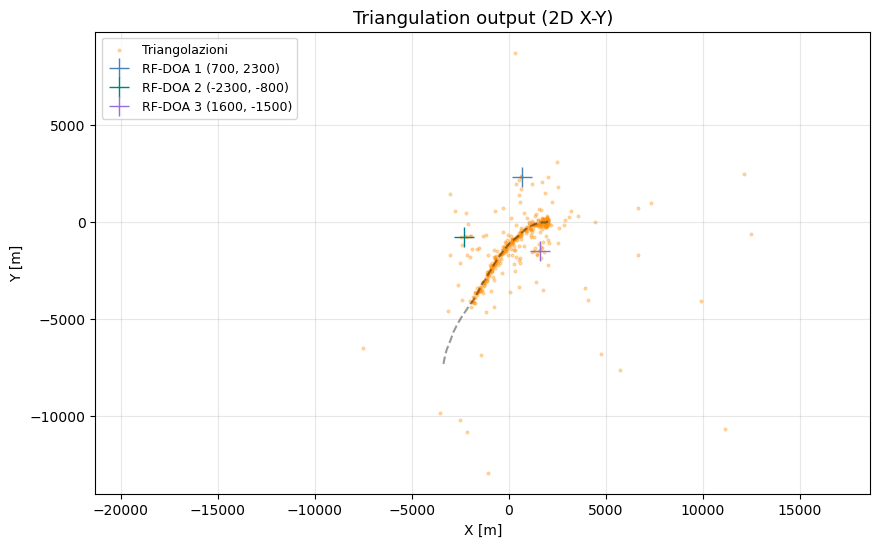

In [29]:


all_tri_xy = np.array([
    [float(d.state_vector[1]) * np.cos(float(d.state_vector[0])),
     float(d.state_vector[1]) * np.sin(float(d.state_vector[0]))]
    for dets in triangulated_all.values()
    for d in dets
]) if total_triang > 0 else np.zeros((0, 2))

plotter_tri = Plotter(dimension=Dimension.TWO)
plotter_tri.plot_ground_truths(truths, [0, 2], color='black', linestyle='--', alpha=0.4,
                                label='Ground truth')

if len(all_tri_xy) > 0:
    plotter_tri.ax.scatter(all_tri_xy[:, 0], all_tri_xy[:, 1],
                           s=4, alpha=0.3, color='darkorange', label='Triangolazioni')

for (x, y), color, label in zip(SENSOR_POSITIONS, SENSOR_COLORS, SENSOR_LABELS):
    plotter_tri.ax.plot(x, y, '+', color=color, markersize=14, zorder=10, label=label)

plotter_tri.ax.set_title('Triangulation output (2D X-Y)', fontsize=13)
plotter_tri.ax.set_xlabel('X [m]'); plotter_tri.ax.set_ylabel('Y [m]')
plotter_tri.ax.legend(fontsize=9, loc='upper left')
plotter_tri.ax.grid(True, alpha=0.3)
plt.show()

## RF-DOA JPDA Tracker

This block mirrors the radar tracker's architecture but with parameter and design choices specifically adapted to the statistical and physical peculiarities of triangulated RF-DOA detections, reflecting the fact that this tracker consumes synthetic Cartesian pseudo-measurements produced by the triangulation engine rather than direct sensor output.

**Transition model:** same consideration made for the radar.

**Data association:** Identical structure to the radar case.

**Track deletion:** The deleter's patience is doubled relative to radar (`time_steps_since_update = 20` vs. 10). This reflects the lower and more geometry-dependent detection rate of triangulated detections: a target temporarily outside the well-conditioned triangulation region (e.g., near a sensor baseline extension, or briefly visible to only one or two sensors) may go several steps without producing a valid triangulated detection even though it is still physically present, so a shorter deleter would prematurely kill tracks during normal geometric blind spots rather than only during genuine target loss.

**Prior state and initiation:** The prior's Z component is set to 0 m with a 0 m standard deviation since triangulation provides no altitude estimate and an uninformative but plausible altitude prior is needed to keep the UKF's nonlinear sigma-point propagation numerically sensible. `min_points=70` is far higher than the radar tracker's 10, reflecting a much stricter confirmation requirement: triangulated detections are far more prone to transient ghost clusters than raw radar returns, so a much longer consistency requirement is needed to reject spurious candidate tracks before they're confirmed. `updates_only=False` (versus `True` for radar) allows the initiator to retain predicted (non-updated) states in the candidate track's history, which is more tolerant of the sparser, less regular detection cadence typical of triangulated detections.

**Prior state and initiation** The prior fixes the altitude channel to a fully non-informative placeholder: both the Z position and the Z velocity are pinned to zero with zero prior variance. This is a deliberate design choice, not an altitude estimate. RF-DOA triangulation has no elevation observability, and the bearing-only measurement model — which maps the state onto the XY plane through indices (0, 2) — never updates the Z channel, so any altitude the filter carried would be a pure artifact of the prior rather than a measurement-driven quantity. Assigning Z a zero mean and zero variance makes this absence of information explicit; the constant-velocity transition model still injects a small process-noise variance on Z at each prediction step, so the filter remains well defined, but the resulting altitude is a random walk anchored to zero, not an estimate. The six-dimensional state is retained purely for structural coherence with the radar tracker (or for future further improvements), so that RF-DOA tracks inhabit the same 3D state space as the radar and the ground truth and can be represented, compared, and fed to the downstream fusion under a single uniform interface. This retention is harmless precisely because the RF-DOA altitude never enters the fusion: the GM-PHD/Chernoff stage operates on the XY sub-state alone, and the fused altitude is sourced exclusively from the `radar, the only sensor with genuine elevation observability`.
min_points is far stricter than the radar tracker's min_points, reflecting the different reliability of the two detection streams: triangulated detections are considerably more prone to transient ghost clusters than raw radar returns, so a much longer consistency requirement is needed to reject spurious candidate tracks before they are confirmed. updates_only = False (versus True for the radar) lets the initiator retain predicted, non-updated states in the candidate track's history, which is more tolerant of the sparser, less regular detection cadence typical of triangulated detections.

**Tracker assembly:** `JPDA_rfdoa_tracker` is fed by `triang_for_tracker` containing exclusively triangulated Cartesian pseudo-detections, with no direct dependency on radar data.

In [30]:
## UKF Predictor e Updater - RF-DOA Tracker

ukf_trans_mod_rfdoa = CombinedGaussianTransitionModel([
    
    ConstantVelocity(q),
    ConstantVelocity(q),
    ConstantVelocity(q),
])

predictor_rfdoa = UnscentedKalmanPredictor(ukf_trans_mod_rfdoa)
updater_rfdoa   = UnscentedKalmanUpdater(measurement_model=None)


In [31]:
## JPDA Data Associator - RF-DOA Tracker

hypothesiser_rfdoa = PDAHypothesiser(
    predictor               = predictor_rfdoa,
    updater                 = updater_rfdoa,
    clutter_spatial_density = 5e-10,
    prob_detect             = Pd_rfdoa,
)
data_associator_rfdoa = JPDA(hypothesiser=hypothesiser_rfdoa)


In [32]:
## Deleter - RF-DOA Tracker

deleter_rfdoa = UpdateTimeStepsDeleter(time_steps_since_update=20)

In [33]:
## MultiMeasurementInitiator - RF-DOA Tracker
# (CartesianToBearingRange with geometry-dependent covariance -> ReversibleModel).

origin_meas_model_rfdoa = CartesianToBearingRange(
    ndim_state         = 6,
    mapping            = (0, 2),
    noise_covar        = np.diag([np.deg2rad(5.0) ** 2, 500.0 ** 2]),
    translation_offset = StateVector([[0], [0]]),
)


prior_state_rfdoa = GaussianState(
    state_vector = StateVector([[0], [0], [0], [0], [0], [0]]),
    #state_vector = StateVector([[0], [0], [0], [0]]),
    covar        = np.diag([1000, 50, 1000, 50, 0, 0])**2,
    #covar        = np.diag([1000, 50, 1000, 50])**2,
    timestamp    = start_time,
)

initiator_rfdoa = MultiMeasurementInitiator(
    prior_state         = prior_state_rfdoa,
    measurement_model   = origin_meas_model_rfdoa,   # fallback
    deleter             = deleter_rfdoa,
    data_associator     = NearestNeighbour(hypothesiser_rfdoa),
    updater             = updater_rfdoa,
    min_points          = 70,                   
    updates_only        = False,
    skip_non_reversible = True,
)


In [34]:
## MultiTargetMixtureTracker - RF-DOA (JPDA)

JPDA_rfdoa_tracker = MultiTargetMixtureTracker(
    initiator       = initiator_rfdoa,
    deleter         = deleter_rfdoa,
    detector        = triang_for_tracker,   
    data_associator = data_associator_rfdoa,
    updater         = updater_rfdoa,
)

In [35]:
## RF-DOA Tracking Loop

rfdoa_tracks_all = set()
rfdoa_snaps = []
for time, ctracks in JPDA_rfdoa_tracker:
    rfdoa_tracks_all.update(ctracks)
    rfdoa_snaps.append((time, {Track([deepcopy(tr.state)], id=tr.id) for tr in ctracks}))

MIN_TRACK_LEN_RFDOA = max(100, int(num_steps * 0.05))
rfdoa_long_tracks = {t for t in rfdoa_tracks_all if len(t.states) >= MIN_TRACK_LEN_RFDOA}

print(f'Total RF-DOA system tracks: {len(rfdoa_tracks_all)}')
print(f'Tracks longer than {MIN_TRACK_LEN_RFDOA} states: {len(rfdoa_long_tracks)}')
print(f'Ground truth paths: {len(truths)}')

/opt/anaconda3/envs/cdfusion/lib/python3.10/site-packages/stonesoup/functions/__init__.py:225: UserWarning: LinAlgError('Matrix is not positive definite')
  warnings.warn(repr(e))


Total RF-DOA system tracks: 4
Tracks longer than 100 states: 1
Ground truth paths: 1


/var/folders/l_/zdf9yxfx6jvblmyt0jgt45xr0000gn/T/ipykernel_37201/1432630421.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_rfdoa = plt.cm.get_cmap('tab10', max(len(rfdoa_long_tracks), 1))


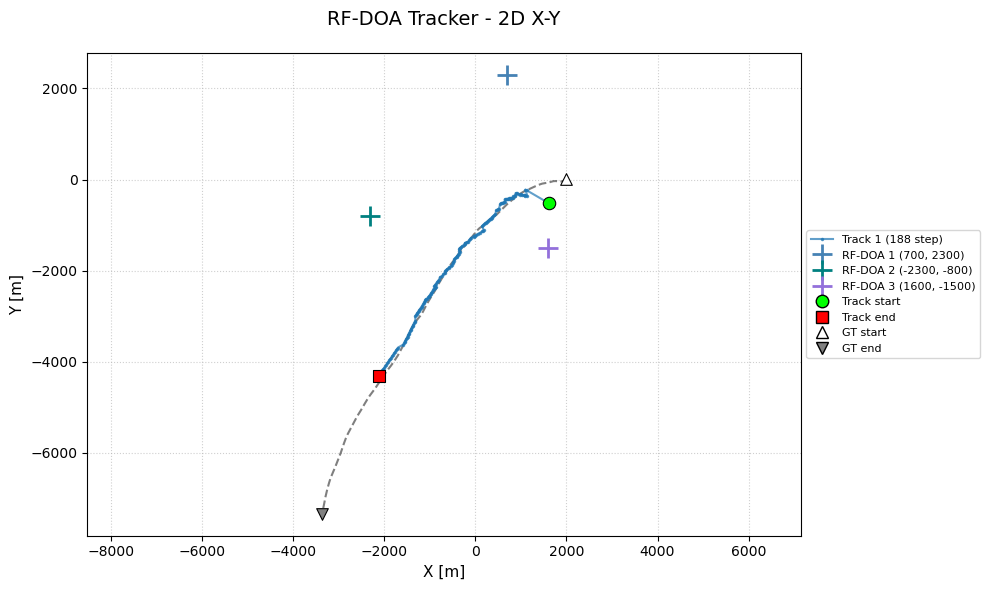

In [36]:
### RF-DOA Tracker - Plot 2D (X-Y)

colors_rfdoa = plt.cm.get_cmap('tab10', max(len(rfdoa_long_tracks), 1))

plotter2d_rfdoa = Plotter(dimension=Dimension.TWO)
plotter2d_rfdoa.plot_ground_truths(truths, [0, 2], color='black', linestyle='--',
                              alpha=0.5, label='Ground truth')

for i, track in enumerate(sorted(rfdoa_long_tracks, key=lambda t: -len(t.states))):
    tx = [s.state_vector[0, 0] for s in track.states]
    ty = [s.state_vector[2, 0] for s in track.states]
    plotter2d_rfdoa.ax.plot(tx, ty, marker='.', markersize=3, linewidth=1.5,
                      color=colors_rfdoa(i), alpha=0.7, label=f'Track {i+1} ({len(track.states)} step)')

for (x, y), color, label in zip(SENSOR_POSITIONS, SENSOR_COLORS, SENSOR_LABELS):
    plotter2d_rfdoa.ax.plot(x, y, '+', color=color, markersize=14, markeredgewidth=2,
                      zorder=10, label=label)

plotter2d_rfdoa.ax.set_title('RF-DOA Tracker - 2D X-Y', fontsize=14, pad=20)
plotter2d_rfdoa.ax.set_xlabel('X [m]', fontsize=11); plotter2d_rfdoa.ax.set_ylabel('Y [m]', fontsize=11)
plotter2d_rfdoa.ax.grid(True, linestyle=':', alpha=0.6)
plotter2d_rfdoa.ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout(); 

plot_track_endpoints(plotter2d_rfdoa.ax, rfdoa_long_tracks)
plot_gt_endpoints(plotter2d_rfdoa.ax, truths)

handles, labels = plotter2d_rfdoa.ax.get_legend_handles_labels()
plotter2d_rfdoa.ax.legend(handles=handles + ENDPOINT_LEGEND,
                          loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)


plt.show()


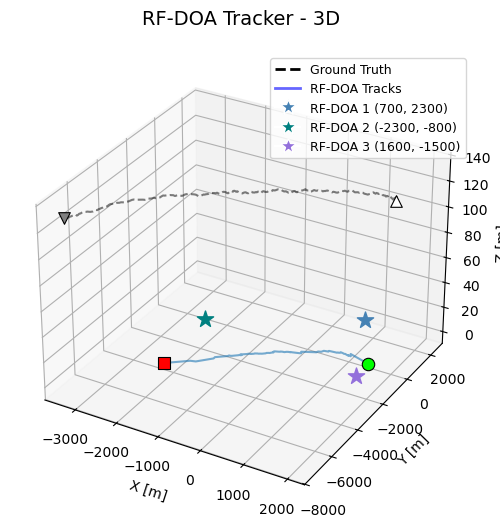

In [37]:
### RF-DOA Tracker - Plot 3D

plotter3d_rfdoa = Plotter(dimension=Dimension.THREE)
plotter3d_rfdoa.plot_ground_truths(truths, [0, 2, 4], color='black', linestyle='--', alpha=0.5)

for i, track in enumerate(sorted(rfdoa_long_tracks, key=lambda t: -len(t.states))):
    tx = [s.state_vector[0, 0] for s in track.states]
    ty = [s.state_vector[2, 0] for s in track.states]
    tz = [s.state_vector[4, 0] for s in track.states]
    plotter3d_rfdoa.ax.plot(tx, ty, tz, linewidth=1.5, color=colors_rfdoa(i), alpha=0.6)

for (x, y), color, label in zip(SENSOR_POSITIONS, SENSOR_COLORS, SENSOR_LABELS):
    plotter3d_rfdoa.ax.scatter(x, y, 0, color=color, s=150, marker='*', zorder=10, label=label)

custom_lines_rfdoa = [
    Line2D([0],[0], color='black', lw=2, linestyle='--'),
    Line2D([0],[0], color='blue',  lw=2, alpha=0.6),
    *[Line2D([0],[0], marker='*', color='w', markerfacecolor=c, markersize=12)
      for c in SENSOR_COLORS],
]
plotter3d_rfdoa.ax.legend(custom_lines_rfdoa,
                    ['Ground Truth', 'RF-DOA Tracks'] + SENSOR_LABELS,
                    loc='upper right', fontsize=9)
plotter3d_rfdoa.ax.set_title('RF-DOA Tracker - 3D', fontsize=14, pad=20)
plotter3d_rfdoa.ax.set_xlabel('X [m]'); plotter3d_rfdoa.ax.set_ylabel('Y [m]'); plotter3d_rfdoa.ax.set_zlabel('Z [m]')

plot_track_endpoints_3d(plotter3d_rfdoa.ax, rfdoa_long_tracks)
plot_gt_endpoints_3d(plotter3d_rfdoa.ax, truths)
plt.show()



## RF-DOA Tracker — Track Quality Summary

This block evaluates the RF-DOA tracker's output at a structural level before any trajectory-accuracy analysis, addressing two distinct questions: *how many* tracks were produced relative to the true target count, and *how long* were they.

The distinction between `rfdoa_tracks_all` (total tracks ever produced, including short-lived ones) and `rfdoa_long_tracks` (tracks surviving a minimum-length filter) is conceptually important: the total count reflects the initiator/deleter behavior under ghost triangulations and clutter, while the long-track subset is the operationally relevant one — tracks long enough to represent a genuine sustained target estimate rather than a transient false confirmation. The ratio between the two is a direct diagnostic of how aggressively `min_points=70` and `deleter_rfdoa` are suppressing spurious track formation versus how many ghost detections still survive long enough to accumulate 70 consistent associations.

Track length statistics (mean, max, min as fraction of `num_steps`) indicate coverage quality: a mean length close to `num_steps` suggests continuous tracking through the scenario.

The printed Z-axis note is not cosmetic: it is a formal acknowledgment of a fundamental observability limitation of the RF-DOA-only pipeline. Since `Cartesian2DToBearing` provides no elevation information, the Z component of every RF-DOA track state is driven entirely by the UKF's transition model propagating the initial prior (`z₀ ≈ 1000 m, σ_z = 500 m`) — making it statistically a random walk anchored to a prior rather than a filtered estimate. This caveat directly motivates the track-to-track fusion step, where Z will be sourced from the radar tracker, which has genuine elevation observability via `CartesianToElevationBearingRange`.

In [38]:
## Track Quality Metrics - RF-DOA Tracker

if rfdoa_long_tracks:
    lengths = [len(t.states) for t in rfdoa_long_tracks]
    print('='*65)
    print(f"{'TRACK QUALITY SUMMARY - RF-DOA':^65}")
    print('='*65)
    print(f'Ground truth targets          : {len(truths)}')
    print(f'Total tracks                  : {len(rfdoa_tracks_all)}')
    print(f'Final tracks                  : {len(rfdoa_long_tracks)}')
    print(f'Length - mean                 : {np.mean(lengths):.1f} step')
    print(f'Length - max                  : {np.max(lengths)} step  ({np.max(lengths)/num_steps*100:.0f}%)')
    print(f'Length - min                  : {np.min(lengths)} step')
    print('='*65)
    print()
    print('NOTE on Z coordinate (altitude):')
    print('RF-DOA sensors measure bearing in the XY plane only.')
    print('Z altitude is estimated from the prior and the UKF transition model.')
    print('For accurate 3D tracking, sensors with elevation measurement are required.')
else:
    print('No long tracks found. Consider reducing MIN_TRACK_LEN_RFDOA or min_points.')


                 TRACK QUALITY SUMMARY - RF-DOA                  
Ground truth targets          : 1
Total tracks                  : 4
Final tracks                  : 1
Length - mean                 : 188.0 step
Length - max                  : 188 step  (63%)
Length - min                  : 188 step

NOTE on Z coordinate (altitude):
RF-DOA sensors measure bearing in the XY plane only.
Z altitude is estimated from the prior and the UKF transition model.
For accurate 3D tracking, sensors with elevation measurement are required.


## GM-PHD Tracker for Track fusion

This section will perform track fusion via a Gaussian mixture probability hypothesis density (GM-PHD) algorithm as the tracker for the track-to-track fusion. mo covariance intersection using the `ChernoffUpdater` class.

In [39]:
# ── Filtra gli snapshot: solo tracce confermate, niente ghost/frammenti ──

# Radar: definisci le tracce "buone" con la stessa logica dell'RF-DOA
MIN_TRACK_LEN_RADAR = 20          # soglia da tarare sul tuo radar (vedi nota sotto)
radar_long_tracks = {t for t in radar_tracks if len(t.states) >= MIN_TRACK_LEN_RADAR}

good_radar_ids = {t.id for t in radar_long_tracks}
good_rfdoa_ids = {t.id for t in rfdoa_long_tracks}

print(f"Radar confermate:  {len(good_radar_ids)} / {len(radar_tracks)}")
print(f"RF-DOA confermate: {len(good_rfdoa_ids)} / {len(rfdoa_tracks_all)}")

# Tieni negli snapshot solo le tracce confermate
radar_snaps = [(time, {tr for tr in snap if tr.id in good_radar_ids}) for time, snap in radar_snaps]
rfdoa_snaps = [(time, {tr for tr in snap if tr.id in good_rfdoa_ids}) for time, snap in rfdoa_snaps]

Radar confermate:  2 / 2
RF-DOA confermate: 1 / 4


## Track-to-Track Fusion — Horizontal Covariance-Intersection Fusion with Radar-Sourced Altitude

This section fuses the outputs of the two independent tracking sub-systems built above — the radar JPDA tracker and the RF-DOA JPDA tracker — into a single set of three-dimensional tracks. The design deliberately separates the fusion into two operations that reflect what each sensor can actually observe, and this separation is the central methodological choice of the whole pipeline.

### Rationale: heterogeneous observability

The two sub-systems are not symmetric in their information content. The radar, driven by a `CartesianToElevationBearingRange` measurement model, observes range, azimuth and elevation, and therefore estimates the full three-dimensional position with genuine altitude information. The 3RF-DOA sub-system, built on bearing-only triangulation from three spatially separated sensors, observes only directions in the horizontal plane: it has no elevation observability whatsoever, and the altitude carried by its tracks is a pure artifact of the prior propagated through the transition model rather than a measured quantity.

Fusing the two full six-dimensional states directly would therefore let the fictitious RF-DOA altitude contaminate the fused elevation, degrading a channel that the radar alone estimates correctly. To prevent this, the fusion is decomposed into a genuine multi-sensor fusion restricted to the horizontal sub-state — where both sensors carry real information and can legitimately reinforce each other — followed by a transfer of the altitude channel from the radar alone. Fusion happens only where there is something to fuse; the altitude is not fused but sourced, because only one sensor observes it.

### Stage A — Projection onto the horizontal sub-state

Both trackers emit six-dimensional states laid out as `[x, vx, y, vy, z, vz]`, so the horizontal position-and-velocity block corresponds exactly to indices `[0, 1, 2, 3]`. The helper `slice_xy` projects each single-state snapshot track onto this sub-space by taking the corresponding four entries of the state vector and the `4×4` principal submatrix of the covariance. Track identity and timestamp are preserved, so the projected streams remain time-aligned with their six-dimensional originals. Crucially, the full-state radar snapshots are left untouched: they are still required in Stage C to supply the altitude.

### Stage B — GM-PHD track-to-track fusion in the horizontal plane

The two projected streams are interleaved by a `MultiDataFeeder` and converted into Gaussian detections by `Tracks2GaussianDetectionFeeder`, which turns the most recent state of each track into a measurement living in the same state space as the fuser. Fusion is performed by a `PointProcessMultiTargetTracker` implementing the Gaussian-Mixture PHD recursion, whose per-component update is delegated to a `ChernoffUpdater`. The Chernoff updater realises Covariance Intersection: it combines two Gaussian estimates whose mutual cross-correlation is unknown, which is precisely the track-to-track situation, where the two input tracks may share process history and cannot be assumed independent. Because the inputs are clean tracker outputs rather than raw sensor returns, the clutter spatial density is set to a very small value, and the probabilities of detection and survival are held high. Data association inside the recursion is gated by a `DistanceHypothesiser` using Euclidean distance restricted to the horizontal position (`Euclidean([0, 2])`), so gating is driven by where targets are, not by the velocity components. A `GaussianMixtureReducer` prunes negligible-weight components and merges near-duplicates to keep the mixture compact, and a single broad, low-weight birth component allows new tracks to appear. Components whose weight exceeds the extraction threshold are emitted as confirmed fused tracks. The result of this stage is a set of purely horizontal fused tracks in the `(x, vx, y, vy)` sub-space.

### Stage C — Track-to-track association and altitude transfer

The horizontal fused tracks must now be lifted back to three dimensions by attaching a physically meaningful altitude. This is done by an explicit track-to-track association against the full-state radar tracks, followed by an altitude transfer. For every fused–radar pair, `mean_xy_dist` computes the mean horizontal distance over the timestamps the two tracks share, or infinity if they never overlap in time; these values populate a cost matrix over all fused-versus-radar combinations. A greedy one-to-one assignment then consumes candidate pairs in order of increasing cost, so that each fused track is matched to the single radar track whose horizontal trajectory it follows most closely. Once a fused track is associated with a radar track, the altitude and vertical velocity — together with their variances — are copied from that radar track at each matching timestamp (falling back to the temporally nearest radar state when an exact timestamp is missing). Each six-dimensional state is then reconstructed with a block-diagonal covariance whose horizontal block comes from the fused estimate and whose altitude block comes from the radar; the horizontal-to-vertical cross terms are zero, which is consistent because the two channels are estimated independently by construction.

In [40]:
## ── TRACK-TO-TRACK FUSION — SETUP: horizontal (X-Y) GM-PHD, altitude excluded ─
#
# The fuser operates only on the horizontal sub-state (x, vx, y, vy) = indices [0,1,2,3].
# The RF-DOA tracker has no elevation observability, so the altitude channel is kept
# out of the fusion here and re-attached from the radar in the next cell.

XY_IDX = [0, 1, 2, 3]          # x, vx, y, vy

def slice_xy(snaps):
    """Project the 6D single-state snapshot tracks onto the (x, vx, y, vy) sub-space."""
    out = []
    for time, snap in snaps:
        sub = set()
        for tr in snap:
            s = tr.state
            # Keep the horizontal position/velocity block of the state vector and the
            # corresponding 4x4 principal submatrix of the covariance.
            sv  = StateVector(s.state_vector[XY_IDX, :])
            cov = CovarianceMatrix(s.covar[np.ix_(XY_IDX, XY_IDX)])
            sub.add(Track([GaussianState(sv, cov, timestamp=s.timestamp)], id=tr.id))
        out.append((time, sub))
    return out

# Project both sensor snapshot streams. The original 6D radar_snaps are left intact:
# the full-state radar tracks are still needed to source the altitude in Stage C.
radar_snaps_xy = slice_xy(radar_snaps)
rfdoa_snaps_xy = slice_xy(rfdoa_snaps)

# ── 4D constant-velocity transition model (x and y only) ─────────────────────
tt_trans_mod = CombinedGaussianTransitionModel([
    ConstantVelocity(q),
    ConstantVelocity(q),
])

# Chernoff updater = Covariance Intersection: fuses two Gaussian estimates whose
# mutual cross-correlation is unknown, which is exactly the track-to-track case.
fusion_updater = ChernoffUpdater(measurement_model=None)

# GM-PHD update step wrapped around the Chernoff updater. The clutter density is
# tiny because the "detections" are clean tracker outputs, not raw sensor returns.
phd_updater = PHDUpdater(
    fusion_updater,
    clutter_spatial_density=1E-25,
    prob_detection=0.9,
    prob_survival=0.9,
)

# Association gating in the horizontal plane only (x = 0, y = 2 in the 4D state).
kalman_predictor = ExtendedKalmanPredictor(tt_trans_mod)
base_hypothesiser = DistanceHypothesiser(
    kalman_predictor,
    fusion_updater,
    Euclidean([0, 2]),          # X-Y position only
    missed_distance=5000,
    include_all=False,
)
hypothesiser = GaussianMixtureHypothesiser(base_hypothesiser, order_by_detection=True)

# Prune negligible-weight components and merge near-duplicates to keep the mixture compact.
ch_reducer = GaussianMixtureReducer(
    prune_threshold=1E-10, pruning=True,
    merge_threshold=1000,  merging=True,
)

# Single 4D birth component: broad covariance, low weight, spawned at the origin.
birth_covar = CovarianceMatrix(np.diag([3000, 30, 3000, 30]))
ch_birth_component = TaggedWeightedGaussianState(
    state_vector=[0, 0, 0, 0],
    covar=birth_covar**2,
    weight=0.25,
    tag=TaggedWeightedGaussianState.BIRTH,
    timestamp=start_time,
)

# The two projected streams are interleaved by the MultiDataFeeder and converted to
# Gaussian detections; the GM-PHD recursion fuses them in the horizontal plane.
track_fusion_tracker = PointProcessMultiTargetTracker(
    detector=Tracks2GaussianDetectionFeeder(
        MultiDataFeeder([iter(radar_snaps_xy), iter(rfdoa_snaps_xy)])
    ),
    hypothesiser=hypothesiser,
    updater=phd_updater,
    reducer=deepcopy(ch_reducer),
    birth_component=deepcopy(ch_birth_component),
    extraction_threshold=0.90,
)

Fused 2D tracks (GM-PHD): 3
Fused b33ef5df <-> Radar a65b9d2c  (mean XY dist = 2.5 m)
Fused dd716ddf <-> Radar 53c0234f  (mean XY dist = 15.3 m)
3D fused tracks produced: 2


/var/folders/l_/zdf9yxfx6jvblmyt0jgt45xr0000gn/T/ipykernel_37201/463128032.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_fused = plt.cm.get_cmap('plasma', max(len(fused_tracks), 1))


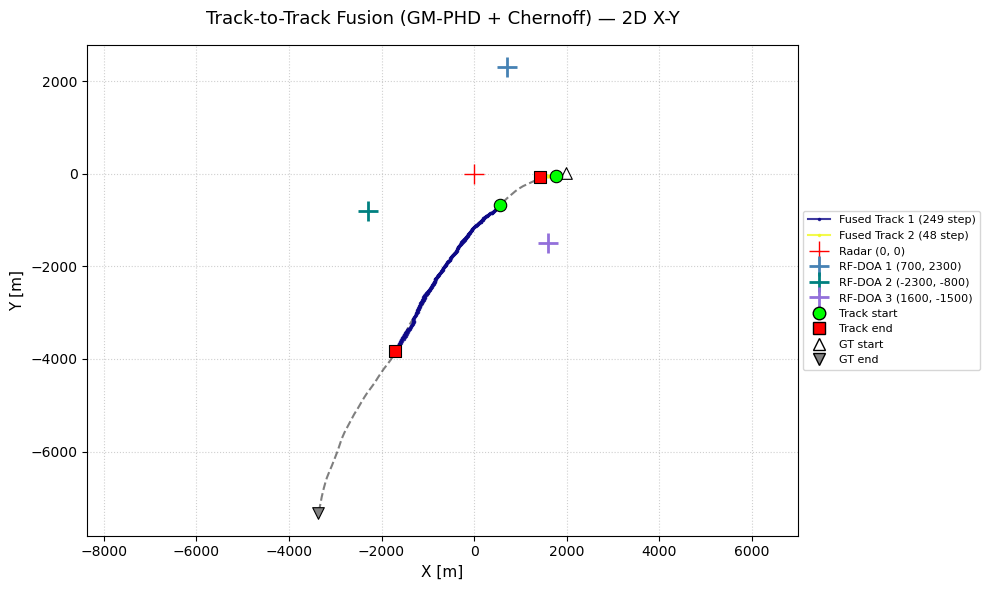

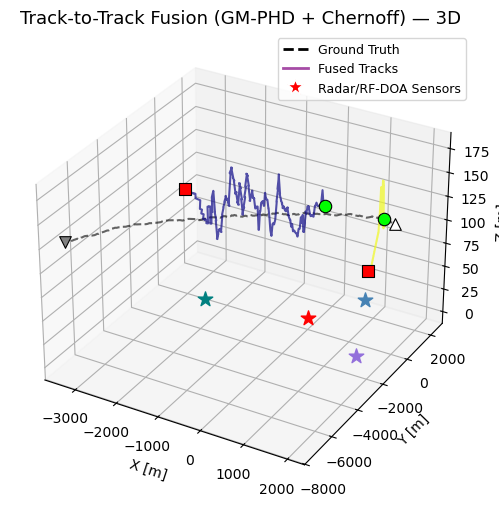

In [41]:
## ── TRACK-TO-TRACK FUSION — RUN: horizontal loop + radar-Z transfer + plots ───

# 1) Run the GM-PHD fusion in the horizontal (x, vx, y, vy) sub-space.
fused_tracks_xy = set()
for time, ctracks in track_fusion_tracker:
    fused_tracks_xy.update(ctracks)
fused_tracks_xy = {t for t in fused_tracks_xy if len(t) > 1}
print(f'Fused 2D tracks (GM-PHD): {len(fused_tracks_xy)}')


## ── TRACK-TO-TRACK ASSOCIATION (XY) + ALTITUDE TRANSFER ──────────────────────
# Step 1: associate each fused (XY) track with the most XY-consistent radar track.
# Step 2: transfer Z and vz FROM that radar track. One-to-one greedy assignment.

def xy_lookup(track):
    """Map timestamp -> (x, y) for every state of a track."""
    return {s.timestamp: (s.state_vector[0, 0], s.state_vector[2, 0]) for s in track.states}

def z_lookup(track):
    """Map timestamp -> (z, vz, var_z, var_vz) for every state of a radar track."""
    out = {}
    for s in track.states:
        z_var  = s.covar[4, 4] if getattr(s, 'covar', None) is not None else 300.0**2
        vz_var = s.covar[5, 5] if getattr(s, 'covar', None) is not None else 30.0**2
        out[s.timestamp] = (s.state_vector[4, 0], s.state_vector[5, 0], z_var, vz_var)
    return out

def mean_xy_dist(fused, radar_xy):
    """Mean XY distance over the shared timestamps; inf if the tracks never overlap."""
    ds = []
    for s in fused.states:
        p = radar_xy.get(s.timestamp)
        if p is not None:
            ds.append(((s.state_vector[0, 0] - p[0])**2 +
                       (s.state_vector[2, 0] - p[1])**2) ** 0.5)
    return np.mean(ds) if ds else np.inf

def associate_and_lift(fused_xy, radar_tracks):
    radar_list = list(radar_tracks)
    radar_xy   = [xy_lookup(rt) for rt in radar_list]
    fused_list = list(fused_xy)

    # Cost matrix: mean XY distance (fused track i x radar track j).
    cost = np.array([[mean_xy_dist(f, rxy) for rxy in radar_xy] for f in fused_list])

    # Greedy one-to-one match: consume candidate pairs in order of increasing cost.
    pairs, used_f, used_r = [], set(), set()
    order = np.dstack(np.unravel_index(np.argsort(cost, axis=None), cost.shape))[0]
    for fi, ri in order:
        if fi in used_f or ri in used_r or not np.isfinite(cost[fi, ri]):
            continue
        pairs.append((fi, ri)); used_f.add(fi); used_r.add(ri)

    out = set()
    for fi, ri in pairs:
        f, r = fused_list[fi], radar_list[ri]
        zmap  = z_lookup(r)
        r_ts  = sorted(zmap)
        print(f"Fused {str(f.id)[:8]} <-> Radar {str(r.id)[:8]}  "
              f"(mean XY dist = {cost[fi, ri]:.1f} m)")
        states6d = []
        for s in f.states:
            # Altitude from the ASSOCIATED radar track: exact timestamp, else nearest.
            if s.timestamp in zmap:
                z, vz, zv, vzv = zmap[s.timestamp]
            else:
                t_near = min(r_ts, key=lambda t: abs((t - s.timestamp).total_seconds()))
                z, vz, zv, vzv = zmap[t_near]
            # Rebuild the 6D state: horizontal channels from the fusion, Z/vz from the radar.
            sv6 = StateVector([[s.state_vector[0, 0]], [s.state_vector[1, 0]],
                               [s.state_vector[2, 0]], [s.state_vector[3, 0]],
                               [z], [vz]])
            # Block-diagonal covariance: XY block from the fused estimate, Z block from
            # the radar; XY-Z cross terms are zero by construction (independent channels).
            C6 = np.zeros((6, 6))
            C6[np.ix_([0, 1, 2, 3], [0, 1, 2, 3])] = s.covar
            C6[4, 4], C6[5, 5] = zv, vzv
            states6d.append(GaussianState(sv6, CovarianceMatrix(C6), timestamp=s.timestamp))
        out.add(Track(states6d, id=f.id))
    return out

fused_tracks = associate_and_lift(fused_tracks_xy, radar_long_tracks)
print(f'3D fused tracks produced: {len(fused_tracks)}')

# ── 2D plot (X-Y) ────────────────────────────────────────────────────────────
colors_fused = plt.cm.get_cmap('plasma', max(len(fused_tracks), 1))

plotter2d_fused = Plotter(dimension=Dimension.TWO)
plotter2d_fused.plot_ground_truths(truths, [0, 2], color='black',
                                   linestyle='--', alpha=0.5, label='Ground truth')

for i, track in enumerate(sorted(fused_tracks, key=lambda t: -len(t.states))):
    tx = [s.state_vector[0, 0] for s in track.states]
    ty = [s.state_vector[2, 0] for s in track.states]
    plotter2d_fused.ax.plot(tx, ty, marker='.', markersize=3, linewidth=1.5,
                            color=colors_fused(i), alpha=0.8,
                            label=f'Fused Track {i+1} ({len(track.states)} step)')

plotter2d_fused.ax.plot(0, 0, 'r+', markersize=14, zorder=10, label='Radar (0, 0)')
for (x, y), color, label in zip(SENSOR_POSITIONS, SENSOR_COLORS, SENSOR_LABELS):
    plotter2d_fused.ax.plot(x, y, '+', color=color, markersize=14,
                            markeredgewidth=2, zorder=10, label=label)

plotter2d_fused.ax.set_title('Track-to-Track Fusion (GM-PHD + Chernoff) — 2D X-Y',
                              fontsize=13, pad=15)
plotter2d_fused.ax.set_xlabel('X [m]', fontsize=11)
plotter2d_fused.ax.set_ylabel('Y [m]', fontsize=11)
plotter2d_fused.ax.grid(True, linestyle=':', alpha=0.6)

plot_track_endpoints(plotter2d_fused.ax, fused_tracks)
plot_gt_endpoints(plotter2d_fused.ax, truths)

handles, labels_leg = plotter2d_fused.ax.get_legend_handles_labels()
plotter2d_fused.ax.legend(handles=handles + ENDPOINT_LEGEND,
                          loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

# ── 3D plot (X-Y-Z) ──────────────────────────────────────────────────────────
plotter3d_fused = Plotter(dimension=Dimension.THREE)
plotter3d_fused.plot_ground_truths(truths, [0, 2, 4], color='black',
                                   linestyle='--', alpha=0.6)

for i, track in enumerate(sorted(fused_tracks, key=lambda t: -len(t.states))):
    tx = [s.state_vector[0, 0] for s in track.states]
    ty = [s.state_vector[2, 0] for s in track.states]
    tz = [s.state_vector[4, 0] for s in track.states]
    plotter3d_fused.ax.plot(tx, ty, tz, linewidth=1.5,
                            color=colors_fused(i), alpha=0.7)

plotter3d_fused.ax.scatter(0, 0, 0, color='red', s=120, marker='*',
                           label='Radar (0,0)', zorder=10)
for (x, y), color, label in zip(SENSOR_POSITIONS, SENSOR_COLORS, SENSOR_LABELS):
    plotter3d_fused.ax.scatter(x, y, 0, color=color, s=120, marker='*',
                               zorder=10, label=label)

custom_lines_fused = [
    Line2D([0], [0], color='black', lw=2, linestyle='--'),
    Line2D([0], [0], color='purple', lw=2, alpha=0.7),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='red', markersize=12),
]
plotter3d_fused.ax.legend(custom_lines_fused,
                          ['Ground Truth', 'Fused Tracks', 'Radar/RF-DOA Sensors'],
                          loc='upper right', fontsize=9)
plotter3d_fused.ax.set_title('Track-to-Track Fusion (GM-PHD + Chernoff) — 3D',
                              fontsize=13)
plotter3d_fused.ax.set_xlabel('X [m]')
plotter3d_fused.ax.set_ylabel('Y [m]')
plotter3d_fused.ax.set_zlabel('Z [m]')

plot_track_endpoints_3d(plotter3d_fused.ax, fused_tracks)
plot_gt_endpoints_3d(plotter3d_fused.ax, truths)
plt.show()

## Performance Evaluation Metrics

This section quantitatively evaluates the three tracking systems developed above — the radar JPDA tracker, the RF-DOA JPDA tracker, and the GM-PHD/Covariance-Intersection fusion — against the simulated ground truth. The evaluation follows the standard four-step assessment process for multi-target tracking [Blair, 2008]: (i) track estimates and truth states are collected at common scoring times; (ii) tracks are associated one-to-one with truth objects; (iii) per-assignment metrics are computed; (iv) results are aggregated into summary statistics and time series. Two complementary metric families are employed: the OSPA distance [Schuhmacher, Vo & Vo, 2008], a single rigorous miss-distance between the *set* of tracks and the *set* of truths, and the SIAP attributes [SIAP SE TF TR 2001-003], a suite of scalar scores that separate the distinct aspects of tracking quality (coverage, precision, false tracks, redundancy). All metrics are computed with Stone Soup's `MultiManager`.

### Track-to-truth association

Every track-based metric is defined only *after* deciding which track corresponds to which truth object. Following the gated-assignment methodology of the SIAP technical report, the `TrackToTruth` associator declares a track-truth pairing admissible only if their distance, evaluated with the same position measure used for scoring, remains below an association threshold (the *gate*). Tracks that satisfy no gate are **spurious**; truth objects with no associated track are **untracked**. The association is re-evaluated over time, so a track may be associated only for part of its life.

### OSPA distance

The Optimal SubPattern Assignment (OSPA) metric ,based on a Wasserstein construction, is a mathematically consistent miss-distance between two finite sets — the set of estimated track states $X = \{x_1,\dots,x_m\}$ and the set of true target states $Y = \{y_1,\dots,y_n\}$ at a given time, where $X, Y$ are subset of $W$. For order $p \ge 1$, cutoff $c > 0$, and $m \le n$:

$$
\bar{d}_p^{(c)}(X, Y) \;=\; \left( \frac{1}{n} \left( \min_{\pi \in \Pi_n} \sum_{i=1}^{m} d^{(c)}\!\big(x_i, y_{\pi(i)}\big)^p \;+\; c^p\,(n - m) \right) \right)^{1/p}
$$

where $d^{(c)}(x,y) = \min\big(c,\; d(x,y)\big)$ is the base distance between $x,y$ cut off at $c$, and $\Pi_n$ is the set of permutations (the optimal point-to-point assignment, computed via the Hungarian algorithm). The metric is bounded in $[0, c]$ and, for $p = 1$, decomposes additively into a **localization** component (mean matched-pair distance) and a **cardinality** component that charges exactly $c$ for every missed or false track:

$$
\bar{e}_{p,\text{loc}}^{(c)} = \left( \frac{1}{n}\min_{\pi \in \Pi_n} \sum_{i=1}^{m} d^{(c)}(x_i, y_{\pi(i)})^p \right)^{1/p},
\qquad
\bar{e}_{p,\text{card}}^{(c)} = \left( \frac{c^p (n-m)}{n} \right)^{1/p}.
$$

**Interpretation of the parameters.** With $p = 1$ the OSPA value reads directly as a *per-target error in metres*. The cutoff $c$ sets the penalty for a missing or false track and thus balances cardinality against localization: $c$ must be chosen well above the typical localization error (otherwise the metric saturates at $c$ and loses discriminative power) and well below the scene scale (otherwise cardinality errors dominate everything). Here $c = 50\,$m is used for the 2D evaluation and $c = 100\,$m for the 3D evaluation, consistent with position accuracies of roughly $15$–$30\,$m observed in this scenario.

### SIAP attributes

The Single Integrated Air Picture (SIAP) attributes decompose tracking quality into independent scalar measures, aggregated over all scoring times $t \in [t_{\text{start}}, t_{\text{end}}]$. With $J(t)$ the number of truth objects at time $t$, $J_T(t)$ the number of truth objects with at least one associated track, $N(t)$ the number of tracks, and $N_A(t)$ the number of associated tracks:

**Completeness** — the fraction of truth-object time covered by at least one track (target: 1):

$$
C \;=\; \frac{\sum_t J_T(t)}{\sum_t J(t)}
$$

**Ambiguity** — the average number of tracks assigned per tracked truth object; redundant tracks push it above the ideal value of 1:

$$
A \;=\; \frac{\sum_t N_A(t)}{\sum_t J_T(t)}
$$

**Spuriousness** — the fraction of track time not associated with any truth object (target: 0):

$$
S \;=\; \frac{\sum_t \big[ N(t) - N_A(t) \big]}{\sum_t N(t)}
$$

**Position Accuracy** and **Velocity Accuracy** — the mean position/velocity error computed *only over associated track states* (so they measure precision when tracking, ignoring coverage gaps; target: 0):

$$
PA \;=\; \frac{\sum_t \sum_{n \in D(t)} \mathrm{PA}_n(t)}{\sum_t N_A(t)},
\qquad
VA \;=\; \frac{\sum_t \sum_{n \in D(t)} \mathrm{VA}_n(t)}{\sum_t N_A(t)}
$$

where $D(t)$ is the set of associated tracks at time $t$ and $\mathrm{PA}_n(t)$, $\mathrm{VA}_n(t)$ are the distances (under the chosen position/velocity measures) between track $n$ and its assigned truth.

The Stone Soup implementation also reports the time-indexed versions of these attributes (completeness, ambiguity, spuriousness and accuracies *at each time*), plus two continuity measures: **Longest Track Segment** (the fraction of each target's lifetime covered by the single longest associated track, sensitive to fragmentation) and **Rate of Track Number Change** (how often the identity of the track covering a target switches).

Note the complementarity with OSPA: SIAP Position Accuracy answers *"how precise is the tracker when it is tracking"*, whereas OSPA additionally charges the cutoff $c$ for every time step in which a target is missed or a false track exists. A tracker with good accuracy but poor completeness (or high spuriousness) therefore shows a low $PA$ but a high OSPA — which is precisely the signature of the standalone RF-DOA system in this scenario.

### Uncertainty: Sum of Covariance Norms

As a measure of the confidence each tracker reports about its own estimates, the Frobenius norms of the state covariance matrices of all live tracks are summed at each time step:

$$
U(t) \;=\; \sum_{n=1}^{N(t)} \big\lVert P_n(t) \big\rVert_F
$$

Lower values indicate tighter (more confident) estimates. This metric is *self-reported* — it does not use the ground truth — so it must be read alongside the accuracy metrics: a small

Set sizes -> radar: 2  rfdoa: 1  fused: 2
2D metrics for: Radar (JPDAF), 3-RFDOA (JPDAF), Covariance Intersection (GM-PHD)


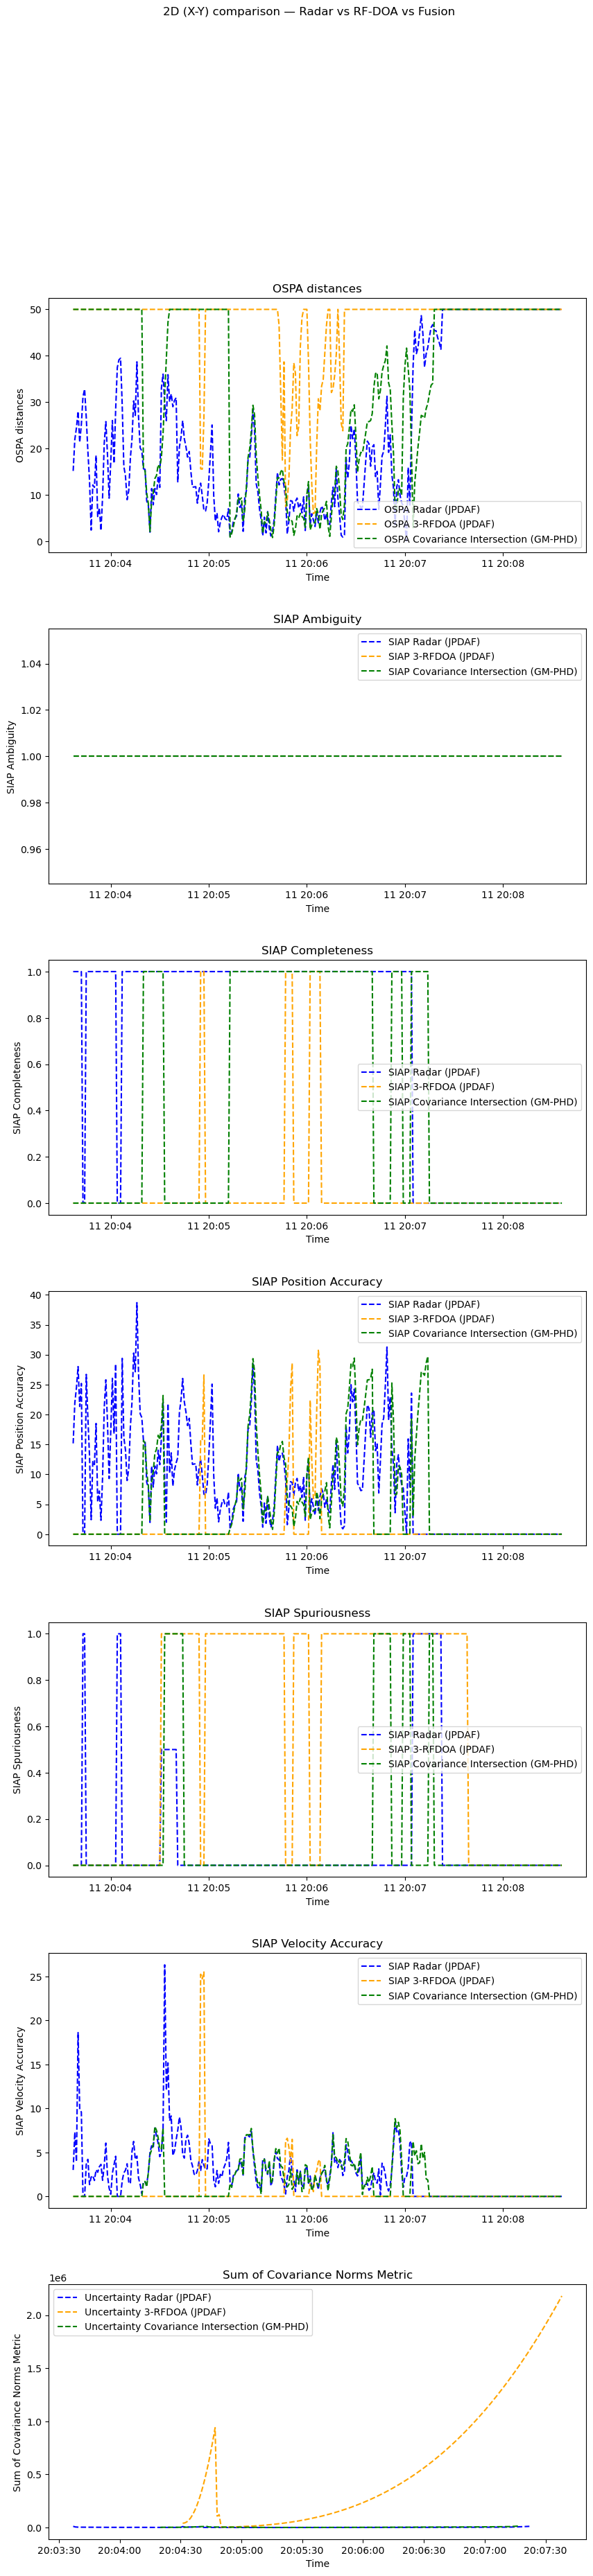

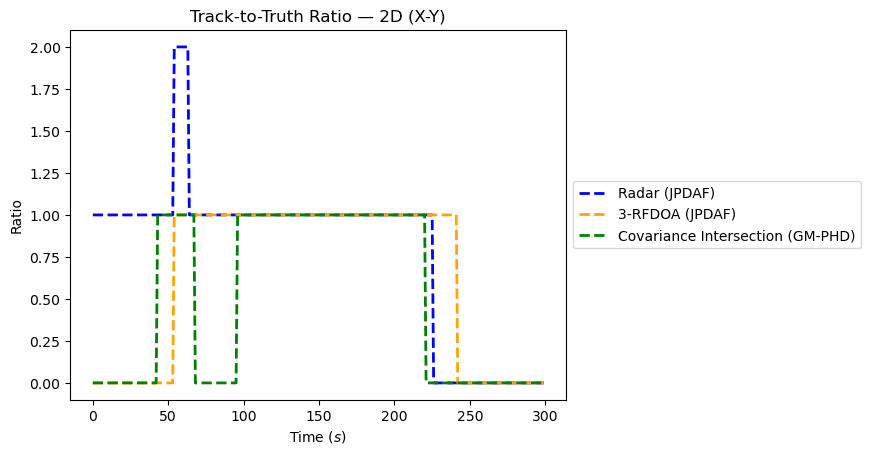

3D metrics for: Radar (JPDAF), Covariance Intersection (GM-PHD)


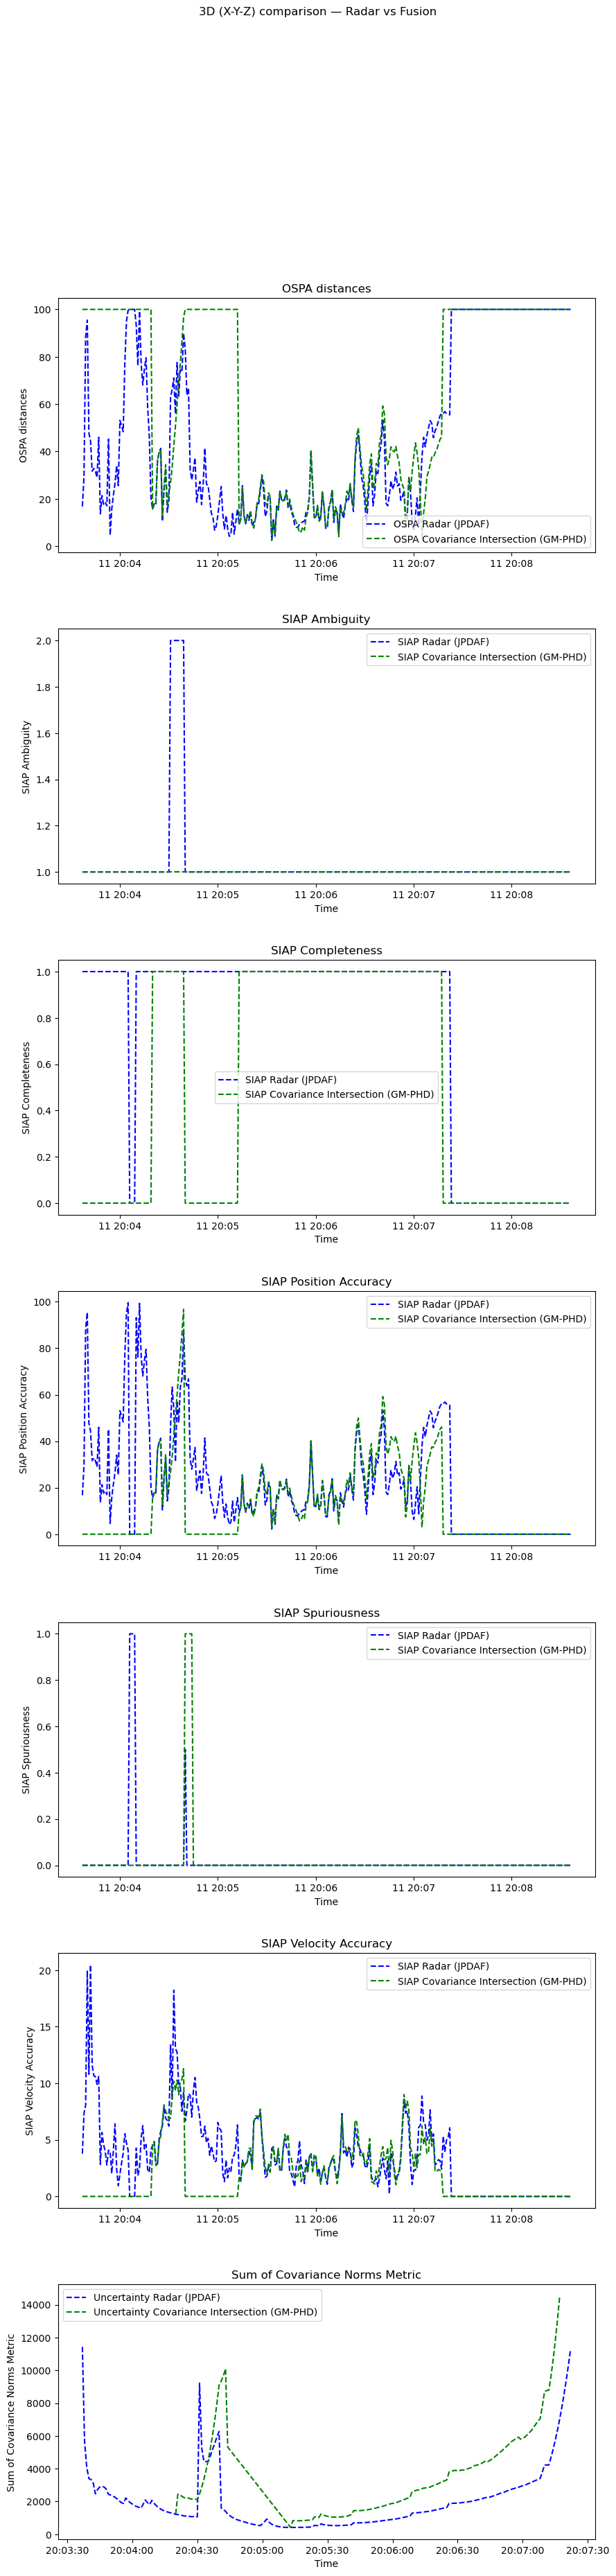

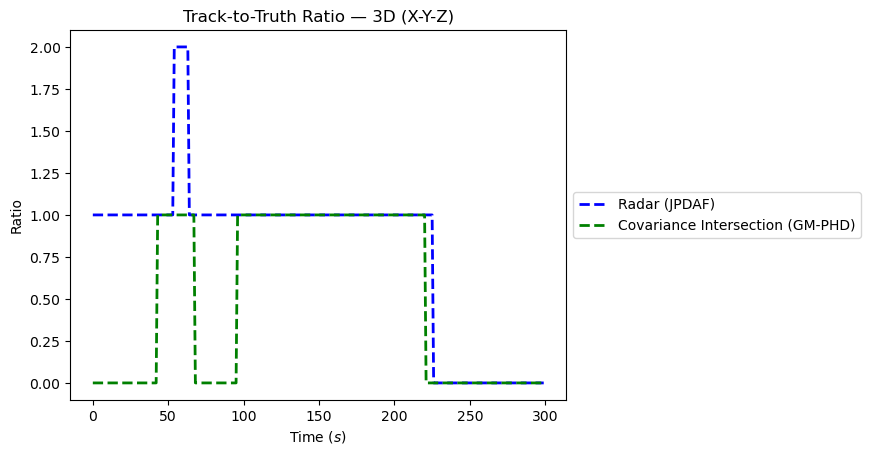

In [42]:
## ── METRIC COMPARISON — 2D (all trackers) + 3D (radar & fusion only) ──────────
from stonesoup.metricgenerator.basicmetrics import BasicMetrics
from stonesoup.metricgenerator.ospametric import OSPAMetric
from stonesoup.metricgenerator.tracktotruthmetrics import SIAPMetrics
from stonesoup.metricgenerator.uncertaintymetric import SumofCovarianceNormsMetric
from stonesoup.dataassociator.tracktotrack import TrackToTruth
from stonesoup.metricgenerator.manager import MultiManager
from stonesoup.measures import Euclidean
from stonesoup.plotter import MetricPlotter
import matplotlib.pyplot as plt

# Track sets — drop single-state tracks (likely clutter), as in the Stone Soup example.
truths_set = set(truths)
radar_set  = {t for t in radar_long_tracks if len(t) > 1}
rfdoa_set  = {t for t in rfdoa_long_tracks if len(t) > 1}
fused_set  = {t for t in fused_tracks      if len(t) > 1}

print(f"Set sizes -> radar: {len(radar_set)}  rfdoa: {len(rfdoa_set)}  fused: {len(fused_set)}")

# Common time axis, taken from the ground truth (robust to empty track sets).
all_times = sorted({s.timestamp for t in truths_set for s in t.states})


def build_manager(systems, pos_map, vel_map, c=10, assoc_threshold=30):
    """systems: list of (key, label, trackset). Empty tracksets are skipped.
    Position/velocity scored on the given maps; the associator uses the same
    position map, so association is consistent with scoring."""
    systems = [(k, l, set(trk)) for k, l, trk in systems if len(set(trk)) > 0]
    if not systems:
        return None, {}, []
    gens = []
    for key, label, _ in systems:
        gens += [
            BasicMetrics(generator_name=f'basic {label}',
                         tracks_key=f'{key}_tracks', truths_key='truths'),
            OSPAMetric(c=c, p=1, measure=Euclidean(pos_map),
                       generator_name=f'OSPA {label}',
                       tracks_key=f'{key}_tracks', truths_key='truths'),
            SIAPMetrics(position_measure=Euclidean(pos_map),
                        velocity_measure=Euclidean(vel_map),
                        generator_name=f'SIAP {label}',
                        tracks_key=f'{key}_tracks', truths_key='truths'),
            SumofCovarianceNormsMetric(generator_name=f'Uncertainty {label}',
                                       tracks_key=f'{key}_tracks'),
        ]
    mgr = MultiManager(gens, associator=TrackToTruth(
        association_threshold=assoc_threshold, measure=Euclidean(pos_map)))
    mgr.add_data({'truths': truths_set}, overwrite=False)
    for key, _, trk in systems:
        mgr.add_data({f'{key}_tracks': trk}, overwrite=False)
    return mgr, mgr.generate_metrics(), systems


def plot_ratio(mgr, systems, title, colors):
    """Track-to-truth ratio over time (live tracks / live truths)."""
    fig, ax = plt.subplots()
    for (key, label, _), col in zip(systems, colors):
        ratios = []
        for time in all_times:
            nt = SIAPMetrics.num_tracks_at_time(mgr.states_sets[f'{key}_tracks'], timestamp=time)
            ng = SIAPMetrics.num_truths_at_time(mgr.states_sets['truths'], timestamp=time)
            ratios.append(nt / ng if ng else 0)
        ax.plot(ratios, linewidth=2, linestyle='--', label=label, color=col)
    ax.set_title(title); ax.set_ylabel('Ratio'); ax.set_xlabel('Time $(s)$')
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))


# ══ Comparison A — 2D (X-Y): all three trackers ══════════════════════════════
# Fair comparison: RF-DOA has no elevation observability, so scoring in XY only
# does not penalise it for a Z channel it cannot estimate.
systems_2d = [
    ('jpda_radar',   'Radar (JPDAF)',                    radar_set),
    ('jpda_3rfdoa',  '3-RFDOA (JPDAF)',                  rfdoa_set),
    ('track_fusion', 'Covariance Intersection (GM-PHD)', fused_set),
]
palette = {'jpda_radar': 'blue', 'jpda_3rfdoa': 'orange', 'track_fusion': 'green'}

mgr2d, metrics2d, sys2d = build_manager(systems_2d, pos_map=[0, 2], vel_map=[1, 3],
                                        c=50, assoc_threshold=30)
if mgr2d is not None:
    print('2D metrics for:', ', '.join(l for _, l, _ in sys2d))
    fig2d = MetricPlotter()
    fig2d.plot_metrics(metrics2d, color=[palette[k] for k, _, _ in sys2d], linestyle='--')
    fig2d.fig.suptitle('2D (X-Y) comparison — Radar vs RF-DOA vs Fusion')
    plot_ratio(mgr2d, sys2d, 'Track-to-Truth Ratio — 2D (X-Y)', [palette[k] for k, _, _ in sys2d])
    plt.show()
else:
    print("2D: no non-empty track sets to compare.")


# ══ Comparison B — 3D (X-Y-Z): radar & fusion only ═══════════════════════════
# Only the sensors that actually observe altitude. RF-DOA is excluded (its Z is a
# fixed non-informative placeholder). Larger association threshold for real Z error.
systems_3d = [
    ('jpda_radar',   'Radar (JPDAF)',                    radar_set),
    ('track_fusion', 'Covariance Intersection (GM-PHD)', fused_set),
]

mgr3d, metrics3d, sys3d = build_manager(systems_3d, pos_map=[0, 2, 4], vel_map=[1, 3, 5],
                                        c=100, assoc_threshold=100)
if mgr3d is not None:
    print('3D metrics for:', ', '.join(l for _, l, _ in sys3d))
    fig3d = MetricPlotter()
    fig3d.plot_metrics(metrics3d, color=[palette[k] for k, _, _ in sys3d], linestyle='--')
    fig3d.fig.suptitle('3D (X-Y-Z) comparison — Radar vs Fusion')
    plot_ratio(mgr3d, sys3d, 'Track-to-Truth Ratio — 3D (X-Y-Z)', [palette[k] for k, _, _ in sys3d])
    plt.show()
else:
    print("3D: no non-empty track sets to compare.")

In [43]:
import numpy as np

def summarize(metrics, systems, tag):
    print(f"\n{'='*62}\n{tag}\n{'='*62}")
    for key, label, _ in systems:
        print(f"\n{label}")
        # OSPA nel tempo — robusto alle diverse strutture di Stone Soup
        try:
            obj = metrics[f'OSPA {label}']
            while isinstance(obj, dict):
                k = next((kk for kk in obj if 'ospa' in kk.lower() or 'dist' in kk.lower()), None)
                obj = obj[k] if k is not None else next(iter(obj.values()))
            seq = obj.value if hasattr(obj, 'value') else obj
            vals = [getattr(m, 'value', m) for m in seq]
            ospa = np.array([float(v) for v in vals if v is not None], dtype=float)
            print(f"  OSPA        mean={ospa.mean():6.2f}  min={ospa.min():6.2f}  max={ospa.max():6.2f}")
        except Exception as e:
            print(f"  OSPA        <n/d: {type(e).__name__}: {e}>")
        # SIAP scalari principali
        for field in ['SIAP Completeness', 'SIAP Ambiguity', 'SIAP Spuriousness',
                      'SIAP Position Accuracy', 'SIAP Velocity Accuracy']:
            try:
                v = metrics[f'SIAP {label}'][field].value
                print(f"  {field:24s}= {float(v):.3f}")
            except Exception:
                pass

summarize(metrics2d, sys2d, "2D (X-Y)  — Radar / RF-DOA / Fusion")
if mgr3d is not None:
    summarize(metrics3d, sys3d, "3D (X-Y-Z) — Radar / Fusion")


2D (X-Y)  — Radar / RF-DOA / Fusion

Radar (JPDAF)
  OSPA        mean= 24.50  min=  0.09  max= 50.00
  SIAP Completeness       = 0.677
  SIAP Ambiguity          = 1.000
  SIAP Spuriousness       = 0.140
  SIAP Position Accuracy  = 12.338
  SIAP Velocity Accuracy  = 3.797

3-RFDOA (JPDAF)
  OSPA        mean= 47.29  min=  5.97  max= 50.00
  SIAP Completeness       = 0.050
  SIAP Ambiguity          = 1.000
  SIAP Spuriousness       = 0.920
  SIAP Position Accuracy  = 17.783
  SIAP Velocity Accuracy  = 8.080

Covariance Intersection (GM-PHD)
  OSPA        mean= 34.03  min=  0.81  max= 50.00
  SIAP Completeness       = 0.397
  SIAP Ambiguity          = 1.000
  SIAP Spuriousness       = 0.207
  SIAP Position Accuracy  = 12.357
  SIAP Velocity Accuracy  = 3.571

3D (X-Y-Z) — Radar / Fusion

Radar (JPDAF)
  OSPA        mean= 48.05  min=  2.22  max=100.00
  SIAP Completeness       = 0.740
  SIAP Ambiguity          = 1.041
  SIAP Spuriousness       = 0.021
  SIAP Position Accuracy  = 30.298
  S

In [44]:
def _ospa_mean(metrics, gen_name, cutoff):
    """OSPA medio nel tempo per un generatore (stessa logica del sanity check)."""
    try:
        obj = metrics[gen_name]
        while isinstance(obj, dict):
            k = next((kk for kk in obj if 'ospa' in kk.lower() or 'dist' in kk.lower()), None)
            obj = obj[k] if k is not None else next(iter(obj.values()))
        seq = obj.value if hasattr(obj, 'value') else obj
        vals = [float(getattr(m, 'value', m)) for m in seq if getattr(m, 'value', m) is not None]
        return float(np.mean(vals)) if vals else float(cutoff)
    except Exception:
        return np.nan

def _siap(metrics, label, field):
    """Scalare SIAP per un tracker; NaN se assente."""
    try:
        return float(metrics[f'SIAP {label}'][field].value)
    except Exception:
        return np.nan

def _ospa_mean(metrics, gen_name, cutoff):
    try:
        obj = metrics[gen_name]
        while isinstance(obj, dict):
            k = next((kk for kk in obj if 'ospa' in kk.lower() or 'dist' in kk.lower()), None)
            obj = obj[k] if k is not None else next(iter(obj.values()))
        seq = obj.value if hasattr(obj, 'value') else obj
        vals = [float(getattr(m, 'value', m)) for m in seq if getattr(m, 'value', m) is not None]
        return float(np.mean(vals)) if vals else float(cutoff)
    except Exception:
        return np.nan

def _siap(metrics, label, field):
    try:
        return float(metrics[f'SIAP {label}'][field].value)
    except Exception:
        return np.nan

def _t2t_ratio_mean(states_sets, tracks_key, truths_key='truths'):
    from stonesoup.metricgenerator.tracktotruthmetrics import SIAPMetrics
    try:
        times = sorted({s.timestamp for t in states_sets[truths_key] for s in t.states})
        ratios = []
        for tm in times:
            nt = SIAPMetrics.num_tracks_at_time(states_sets[tracks_key], timestamp=tm)
            ng = SIAPMetrics.num_truths_at_time(states_sets[truths_key], timestamp=tm)
            if ng:
                ratios.append(nt / ng)
        return float(np.mean(ratios)) if ratios else np.nan
    except Exception:
        return np.nan

In [45]:
_L   = {'T1': 'Radar (JPDAF)', 'T2': '3-RFDOA (JPDAF)', 'Tf': 'Covariance Intersection (GM-PHD)'}
_KEY = {'T1': 'jpda_radar_tracks', 'T2': 'jpda_3rfdoa_tracks', 'Tf': 'track_fusion_tracks'}

row = {'seed': SEED}

# ── TUTTE le metriche 2D, per tutti e tre i tracker ──────────────────────────
for tag in ('T1', 'T2', 'Tf'):
    lab = _L[tag]
    row[f'{tag}_ospa2d'] = _ospa_mean(metrics2d, f'OSPA {lab}', 50)
    row[f'{tag}_compl']  = _siap(metrics2d, lab, 'SIAP Completeness')
    row[f'{tag}_amb']    = _siap(metrics2d, lab, 'SIAP Ambiguity')
    row[f'{tag}_spur']   = _siap(metrics2d, lab, 'SIAP Spuriousness')
    row[f'{tag}_pa2d']   = _siap(metrics2d, lab, 'SIAP Position Accuracy')
    row[f'{tag}_va2d']   = _siap(metrics2d, lab, 'SIAP Velocity Accuracy')
    row[f'{tag}_t2t']    = _t2t_ratio_mean(mgr2d.states_sets, _KEY[tag])

# ── metriche 3D: solo radar e fusione (l'RF-DOA non osserva la quota) ─────────
for tag in ('T1', 'Tf'):
    lab = _L[tag]
    row[f'{tag}_ospa3d'] = _ospa_mean(metrics3d, f'OSPA {lab}', 100)
    row[f'{tag}_pa3d']   = _siap(metrics3d, lab, 'SIAP Position Accuracy')
    row[f'{tag}_va3d']   = _siap(metrics3d, lab, 'SIAP Velocity Accuracy')

# ── conteggi tracce (stratificazione RF-DOA e validità run) ──────────────────
row['radar_ntracks'] = len(radar_set)
row['rfdoa_ntracks'] = len(rfdoa_set)
row['fused_ntracks'] = len(fused_set)

# ── append al CSV ────────────────────────────────────────────────────────────
path = 'montecarlo_final_clean.csv'
write_header = not os.path.exists(path)
with open(path, 'a', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(row.keys()))
    if write_header:
        w.writeheader()
    w.writerow(row)
print(f"Salvato seed {SEED} | radar {row['radar_ntracks']} rfdoa {row['rfdoa_ntracks']} fused {row['fused_ntracks']}")

Salvato seed 53 | radar 2 rfdoa 1 fused 2
